# Thesis Evaluation Analysis
## Chapter 5 — Evaluation of Use Case 1: AI-Assisted RAG for Quantum Software Development

This notebook drives the evaluation section of the thesis.  
Each section maps directly to a thesis subsection (5.1.4 – 5.1.9).

**Sections:**
- [5.1.4 Judge Validity Study](#514-judge-validity-study)
- [5.1.5 Experiment Design Overview](#515-experiment-design-overview)
- [5.1.6 Axis 1 — Search Strategy](#516-axis-1--search-strategy)
- [5.1.7 Axis 2 — RAG Architecture](#517-axis-2--rag-architecture)
- [5.1.8 Axis 3 — LLM Model](#518-axis-3--llm-model)
- [5.1.9 Best Configuration Deep Dive](#519-best-configuration-deep-dive)
- [LaTeX Table Export](#latex-table-export)

Set `SAVE_FIGS = True` to export all figures to `figures/` for thesis inclusion.

---
## Setup

In [1]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

# Color-blind-friendly palette
PALETTE = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']

# ── Figure export ─────────────────────────────────────────────────────────────
SAVE_FIGS = True
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name: str):
    if SAVE_FIGS:
        for ext in ('pdf', 'png'):
            plt.savefig(FIGURES_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=300)
        print(f'  Saved: figures/{name}.(pdf|png)')

In [2]:
# ── MLflow & metric definitions ────────────────────────────────────────────────
MLFLOW_TRACKING_URI = 'http://localhost:8567'
RAGAS_TABLE_ARTIFACT = 'ragas_scores.json'

METRIC_COLS = [
    'faithfulness',
    'context_precision',
    'context_recall',
    'answer_relevance',
    'factual_correctness',
    'factual_correctness_recall',
]

METRIC_SHORT = {
    'faithfulness':             'Faith.',
    'context_precision':        'Ctx.Prec.',
    'context_recall':           'Ctx.Rec.',
    'answer_relevance':         'Ans.Rel.',
    'factual_correctness':      'FC',
    'factual_correctness_recall': 'FCRec.',
}

METRIC_LONG = {
    'faithfulness':             'Faithfulness',
    'context_precision':        'Context Precision',
    'context_recall':           'Context Recall',
    'answer_relevance':         'Answer Relevance',
    'factual_correctness':      'Factual Correctness',
    'factual_correctness_recall': 'FC Recall',
}

EXCLUDE_CLASSES = ['unanswerable']

# ── Run definitions ────────────────────────────────────────────────────────────

# Axis 1: Search Strategy  (fixed: Baseline arch + gpt-4o-mini)
AXIS1_RUNS = [
    ('f6d783f661a644a58865384534021c32', 'Semantic'),
    ('144d504d4b1b454f8505f54697c69250', 'BM25'),
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Hybrid'),
]

# Axis 2: Architecture  (fixed: Hybrid search + gpt-4o-mini)
AXIS2_RUNS = [
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Baseline'),
    ('412a730db5e04a4da436218d6321d1cd', 'Query Rewriting'),
    ('9df381d8997646e797d34917dd394dee', 'RAG Agent'),
]

# Axis 3: LLM Model  (fixed: RAG Agent arch + Hybrid search)
AXIS3_RUNS = [
    ('9df381d8997646e797d34917dd394dee', 'gpt-4o-mini'),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'gemma4:e4b\n(local)'),
    ('801c6a24a60b4f689a38fcdb1de87e49', 'qwen3.5:9b\n(local)'),
    ('9d312a36ef2f4332b200b620919bd202', 'gpt-5.4'),
]

# Reproducibility: same config, two independent runs
REPRO_RUNS = [
    ('f6d783f661a644a58865384534021c32', 'Run 1 (original)'),
    ('79ac6798bfab4f228fdb0cb88a30bb16', 'Run 2 (repeat)'),
]

# Judge comparison: same precomputed answers, 3 different judges
JUDGE_RUNS = [
    ('53fdfeda71b644028d483906ed9cb406', 'gpt-4o-mini'),
    ('c8da3550a0a145f1aac8805d2ee6c733', 'gpt-5.4-mini'),
    ('38c7e3a1d5b14453a2cdb78089fa7df8', 'gpt-5.4'),
]

# Full 3x3 grid: architecture x search strategy (all gpt-4o-mini)
ARCHS    = ['Baseline', 'Query Rewriting', 'RAG Agent']
SEARCHES = ['Semantic', 'BM25', 'Hybrid']
GRID_IDS = {
    ('Baseline',        'Semantic'): 'f6d783f661a644a58865384534021c32',
    ('Baseline',        'BM25'):     '144d504d4b1b454f8505f54697c69250',
    ('Baseline',        'Hybrid'):   '2ebab2b7d6ad46859eab992a06c5ccad',
    ('Query Rewriting', 'Semantic'): '92647f9427f74a0ea710d0cf731ec0ea',
    ('Query Rewriting', 'BM25'):     'e5483a9635b34c8895ecdfabc45674c4',
    ('Query Rewriting', 'Hybrid'):   '412a730db5e04a4da436218d6321d1cd',
    ('RAG Agent',       'Semantic'): '7b33b7a6b88b420e93d6c56f8bca4416',
    ('RAG Agent',       'BM25'):     '2c80aecbb48d4bf68efce97806509159',
    ('RAG Agent',       'Hybrid'):   '9df381d8997646e797d34917dd394dee',
}

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f'Tracking URI: {MLFLOW_TRACKING_URI}')
print(f'Total unique runs to load: ...')

Tracking URI: http://localhost:8567
Total unique runs to load: ...


In [3]:
# ── Helper functions ───────────────────────────────────────────────────────────

def _list_artifacts(run_id: str, path: str = '') -> list:
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(_list_artifacts(run_id, art.path))
    return items


def load_run(run_id: str) -> pd.DataFrame:
    matches = [p for p in _list_artifacts(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f'No {RAGAS_TABLE_ARTIFACT} for {run_id}')
    local = client.download_artifacts(run_id, matches[0])
    with open(local) as f:
        payload = json.load(f)
    if isinstance(payload, list):
        df = pd.DataFrame(payload)
    elif 'data' in payload:
        df = pd.DataFrame(payload['data'], columns=payload['columns'])
    else:
        df = pd.DataFrame(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def mean_scores(df: pd.DataFrame, exclude=EXCLUDE_CLASSES) -> pd.Series:
    """Mean RAGAS scores, optionally excluding question classes."""
    sub = df[~df['question_class'].isin(exclude)] if exclude else df
    return sub[METRIC_COLS].mean(numeric_only=True)


def build_table(runs: list, exclude=EXCLUDE_CLASSES) -> pd.DataFrame:
    """Build a rows=labels, cols=metrics comparison table."""
    rows = {label: mean_scores(all_data[rid], exclude=exclude) for rid, label in runs}
    return pd.DataFrame(rows).T


def styled(df: pd.DataFrame, caption: str = ''):
    """Return a green-red gradient styled DataFrame for display."""
    return (
        df.style
        .format('{:.4f}')
        .background_gradient(axis=0, cmap='RdYlGn', vmin=0.35, vmax=0.95)
        .set_caption(caption)
    )


def plot_grouped_bars(ax, table: pd.DataFrame, title: str, ylim=(0, 1.18)):
    """Grouped bar chart: rows=labels, cols=metrics."""
    metrics = [m for m in METRIC_COLS if m in table.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    labels = list(table.index)
    x = np.arange(len(metrics))
    n = len(labels)
    w = 0.8 / n
    for i, label in enumerate(labels):
        scores = table.loc[label, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        bars = ax.bar(x + offset, scores, w * 0.9, label=label, color=PALETTE[i % len(PALETTE)])
        for bar, v in zip(bars, scores):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha='right')
    ax.set_ylim(*ylim)
    ax.set_ylabel('Mean Score (excl. unanswerable)')
    ax.set_title(title)
    ax.legend(loc='upper right', framealpha=0.8)


def plot_delta_bars(ax, delta: pd.DataFrame, title: str):
    """Grouped delta bar chart vs a baseline row."""
    metrics = [m for m in METRIC_COLS if m in delta.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    labels = list(delta.index)
    x = np.arange(len(metrics))
    n = len(labels)
    w = 0.8 / n
    for i, label in enumerate(labels):
        vals = delta.loc[label, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        colors = [PALETTE[2] if v >= 0 else PALETTE[3] for v in vals]
        for xi, v, c in zip(x + offset, vals, colors):
            ax.bar(xi, v, w * 0.9, color=c,
                   label=label if xi == round(x[0] + offset, 8) else '')
        for xi, v in zip(x + offset, vals):
            if not np.isnan(v) and abs(v) > 0.002:
                ax.text(xi, v + (0.005 if v >= 0 else -0.018),
                        f'{v:+.3f}', ha='center',
                        va='bottom' if v >= 0 else 'top', fontsize=7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha='right')
    ax.set_ylabel('Δ Score')
    ax.set_title(title)
    handles = [mpatches.Patch(color=PALETTE[2], label=lbl) for lbl in labels]
    ax.legend(handles=handles, loc='upper right', framealpha=0.8)


def plot_radar(ax_polar, table: pd.DataFrame, title: str):
    """Radar / spider chart on a polar axes."""
    metrics = [m for m in METRIC_COLS if m in table.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    for i, label in enumerate(table.index):
        vals = table.loc[label, metrics].values.astype(float).tolist()
        vals += vals[:1]
        ax_polar.plot(angles, vals, color=PALETTE[i % len(PALETTE)], linewidth=2, label=label)
        ax_polar.fill(angles, vals, color=PALETTE[i % len(PALETTE)], alpha=0.12)
    ax_polar.set_xticks(angles[:-1])
    ax_polar.set_xticklabels(short, fontsize=8)
    ax_polar.set_ylim(0, 1)
    ax_polar.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax_polar.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6)
    ax_polar.set_title(title, pad=14, fontsize=10)
    ax_polar.legend(loc='upper right', bbox_to_anchor=(1.45, 1.2), fontsize=8)


def plot_score_heatmap(ax, df: pd.DataFrame, title: str,
                       vmin: float = 0.35, vmax: float = 0.95,
                       row_label: str = '', col_label: str = 'Metric'):
    """Heatmap: rows=runs/groups, cols=metrics."""
    metrics = [m for m in METRIC_COLS if m in df.columns]
    data = df[metrics].astype(float)
    cols_short = [METRIC_SHORT[m] for m in metrics]
    im = ax.imshow(data.values, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(cols_short, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(list(data.index), fontsize=9)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data.iloc[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.3f}', ha='center', va='center', fontsize=8,
                        color='black' if 0.4 < v < 0.85 else 'white')
    ax.set_xlabel(col_label)
    if row_label:
        ax.set_ylabel(row_label)
    ax.set_title(title, fontsize=10, fontweight='bold')

print('Helper functions loaded.')

Helper functions loaded.


In [4]:
# ── Load all run data from MLflow ──────────────────────────────────────────────
ALL_RUN_IDS: set = set()
for runs in [AXIS1_RUNS, AXIS2_RUNS, AXIS3_RUNS, REPRO_RUNS, JUDGE_RUNS]:
    for rid, _ in runs:
        ALL_RUN_IDS.add(rid)
ALL_RUN_IDS.update(GRID_IDS.values())

print(f'Loading {len(ALL_RUN_IDS)} unique runs...')
all_data: dict[str, pd.DataFrame] = {}

for run_id in sorted(ALL_RUN_IDS):
    try:
        all_data[run_id] = load_run(run_id)
        print(f'  OK   {run_id[:8]}  ({len(all_data[run_id])} rows)')
    except Exception as e:
        print(f'  FAIL {run_id[:8]}: {e}')

print(f'\nLoaded {len(all_data)}/{len(ALL_RUN_IDS)} runs successfully.')

Loading 16 unique runs...


  OK   144d504d  (20 rows)


  OK   2c80aecb  (20 rows)


  OK   2ebab2b7  (20 rows)


  OK   38c7e3a1  (20 rows)


...

  OK   9d312a36  (20 rows)


  OK   9df381d8  (20 rows)


  OK   c8da3550  (20 rows)


  OK   e5483a96  (20 rows)


  OK   f6d783f6  (20 rows)

Loaded 16/16 runs successfully.


---
<a id='514-judge-validity-study'></a>
## Section 5.1.4 — Judge Validity Study

Before presenting results, we validate the reliability of the LLM-as-a-judge approach used by RAGAS.  
Two concerns are addressed:

1. **Score reproducibility** — does the same configuration produce the same scores when run twice?  
   We use `baseline/semantic/gpt-4o-mini` which was run twice under identical conditions.

2. **Inter-judge agreement** — do different judge LLMs agree on the same answers?  
   We re-evaluate the same precomputed answers using three judges: `gpt-4o-mini`, `gpt-5.4-mini`, `gpt-5.4`.

> **Thesis note:** Use this section to justify which judge was chosen as the fixed judge for all comparative runs, and to disclose any caveats about metric reliability.

### 5.1.4.1 — Score Reproducibility

The same evaluation pipeline (`baseline/semantic/gpt-4o-mini`) was executed twice without changing any parameters.  
Since the judge LLM temperature was not explicitly set to 0 in these runs, non-zero temperature may introduce score variance.

> **Expected finding:** Most metrics should be stable (Δ < 0.05). A larger delta on any metric suggests that metric is sensitive to judge temperature and its absolute values should be interpreted with caution — though relative rankings across runs (which all share the same temperature setting) remain valid.

In [5]:
# ── 5.1.4.1 Reproducibility ────────────────────────────────────────────────────
repro_table = build_table(REPRO_RUNS)
delta_repro = repro_table.loc['Run 2 (repeat)'] - repro_table.loc['Run 1 (original)']

print('Scores — baseline/semantic/gpt-4o-mini run twice:')
display(styled(repro_table, 'Table 5.1.4a: Score Reproducibility — Same Config, Two Runs'))
print()
print('Delta (Run 2 − Run 1):')
display(
    delta_repro.to_frame('Δ score').T
    .style.format('{:+.4f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.15, vmax=0.15, axis=1)
    .set_caption('Δ < ±0.05: negligible | Δ > ±0.05: notable variance')
)

Scores — baseline/semantic/gpt-4o-mini run twice:


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Run 1 (original),0.7185,0.6515,0.5556,0.7929,0.5007,0.6093
Run 2 (repeat),0.6477,0.6339,0.6889,0.7839,0.4767,0.6360



Delta (Run 2 − Run 1):


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Δ score,-0.0709,-0.0176,+0.1333,-0.0090,-0.0240,+0.0267


  Saved: figures/fig_5_1_reproducibility.(pdf|png)


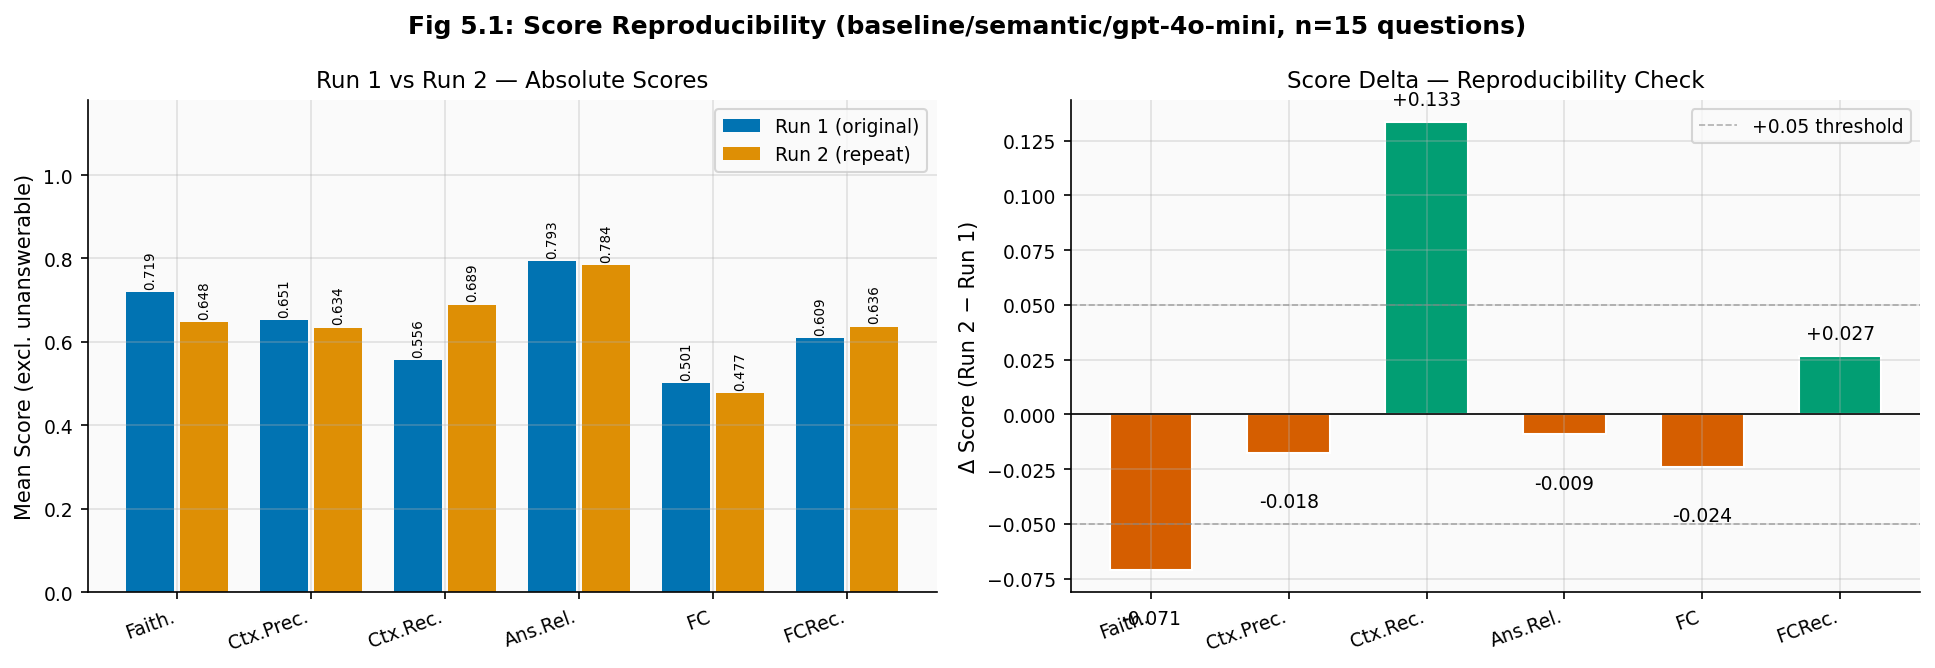

Metrics with |Δ| > 0.05: ['Faith.', 'Ctx.Rec.']
Max |Δ|: 0.1333 on Ctx.Rec.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: side-by-side scores
plot_grouped_bars(ax1, repro_table, 'Run 1 vs Run 2 — Absolute Scores')

# Right: delta chart
metrics = METRIC_COLS
short = [METRIC_SHORT[m] for m in metrics]
x = np.arange(len(metrics))
delta_vals = delta_repro[metrics].values.astype(float)
colors = [PALETTE[2] if v >= 0 else PALETTE[3] for v in delta_vals]
ax2.bar(x, delta_vals, color=colors, edgecolor='white', width=0.6)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(0.05, color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='+0.05 threshold')
ax2.axhline(-0.05, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
for xi, v in zip(x, delta_vals):
    ax2.text(xi, v + (0.006 if v >= 0 else -0.018), f'{v:+.3f}',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(short, rotation=20, ha='right')
ax2.set_ylabel('Δ Score (Run 2 − Run 1)')
ax2.set_title('Score Delta — Reproducibility Check')
ax2.legend()

plt.suptitle('Fig 5.1: Score Reproducibility (baseline/semantic/gpt-4o-mini, n=15 questions)',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_1_reproducibility')
plt.show()

# Summary stats
notable = [METRIC_SHORT[m] for m, v in zip(metrics, delta_vals) if abs(v) > 0.05]
print(f'Metrics with |Δ| > 0.05: {notable if notable else "none"}')
print(f'Max |Δ|: {max(abs(delta_vals)):.4f} on {METRIC_SHORT[metrics[np.argmax(abs(delta_vals))]]}')

### 5.1.4.2 — Multi-Judge Agreement

The same precomputed RAG answers (from run `53fdfeda`, `rag_agent/hybrid/gpt-4o-mini`) were evaluated by three different LLM judges.  
This tests whether the choice of judge LLM significantly affects the reported scores.

**Key questions:**
- Do the judges agree on which questions are answered well/poorly? (Pearson correlation)
- How large is the per-sample disagreement? (mean score range across judges)
- Which metrics are most/least consistent across judges?

> **Thesis note:** High correlation = the metric captures the same signal regardless of judge.  
> Low correlation = the metric is judge-dependent and should be reported with a caveat.

In [7]:
# ── 5.1.4.2 Multi-Judge Comparison ─────────────────────────────────────────────
judge_dfs = {}
judge_labels = []
for rid, label in JUDGE_RUNS:
    df = all_data[rid].copy()
    df['judge'] = label
    judge_dfs[label] = df
    judge_labels.append(label)

# Mean scores per judge
judge_means = pd.DataFrame({
    label: judge_dfs[label][METRIC_COLS].mean(numeric_only=True)
    for label in judge_labels
}).T

print('=== Mean Scores by Judge (same RAG answers, three judges) ===')
display(styled(judge_means, 'Table 5.1.4b: Inter-Judge Score Comparison (same precomputed answers)'))

# Range of means across judges
range_of_means = judge_means.max() - judge_means.min()
print('\nRange of means across judges (high = judges disagree on overall level):')
display(range_of_means.to_frame('range').T.style.format('{:.4f}')
        .background_gradient(cmap='YlOrRd', vmin=0, vmax=0.25, axis=1))

=== Mean Scores by Judge (same RAG answers, three judges) ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
gpt-4o-mini,0.8171,0.5970,0.7500,0.7160,0.5995,0.8268
gpt-5.4-mini,0.6659,0.5596,0.7167,0.7762,0.4895,0.7874
gpt-5.4,0.5996,0.5463,0.8167,0.7298,0.4905,0.6435



Range of means across judges (high = judges disagree on overall level):


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
range,0.2175,0.0507,0.1000,0.0602,0.1100,0.1833


In [8]:
# Align per-sample scores across judges
join_keys = ['user_input', 'subdomain', 'question_class']
wide = None
for label in judge_labels:
    sub = judge_dfs[label][join_keys + METRIC_COLS].copy()
    sub = sub.rename(columns={c: f'{c}__{label}' for c in METRIC_COLS})
    wide = sub if wide is None else wide.merge(sub, on=join_keys, how='inner')

print(f'Aligned samples (inner join across all judges): {len(wide)}')

# Per-sample range across judges
for metric in METRIC_COLS:
    cols = [f'{metric}__{lb}' for lb in judge_labels]
    wide[f'{metric}__range'] = wide[cols].max(axis=1) - wide[cols].min(axis=1)

# Pairwise Pearson correlation
pairs = list(itertools.combinations(judge_labels, 2))
corr_rows = []
for metric in METRIC_COLS:
    row = {'metric': METRIC_SHORT[metric]}
    for left, right in pairs:
        col_l = f'{metric}__{left}'
        col_r = f'{metric}__{right}'
        mask = wide[col_l].notna() & wide[col_r].notna()
        r = wide.loc[mask, col_l].corr(wide.loc[mask, col_r], method='pearson')
        pair_key = f'{left.split("-")[0]} vs {right.split("-")[0]}'
        row[pair_key] = r
    row['mean_sample_range'] = wide[f'{metric}__range'].mean()
    corr_rows.append(row)

corr_df = pd.DataFrame(corr_rows).set_index('metric')
print('\nPairwise Pearson correlation + mean sample range:')
display(
    corr_df.style.format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.2, vmax=1.0, subset=corr_df.columns[:-1])
    .background_gradient(cmap='YlOrRd', vmin=0, vmax=0.35, subset=['mean_sample_range'])
    .set_caption('Table 5.1.4c: Inter-Judge Pairwise Pearson Correlation (1.0 = perfect agreement)')
)

Aligned samples (inner join across all judges): 20

Pairwise Pearson correlation + mean sample range:


,gpt vs gpt,mean_sample_range
metric,,
Faith.,0.625,0.238
Ctx.Prec.,0.897,0.202
Ctx.Rec.,0.390,0.333
Ans.Rel.,0.833,0.080
FC,0.082,0.294
FCRec.,0.352,0.253


  Saved: figures/fig_5_2_judge_validity.(pdf|png)


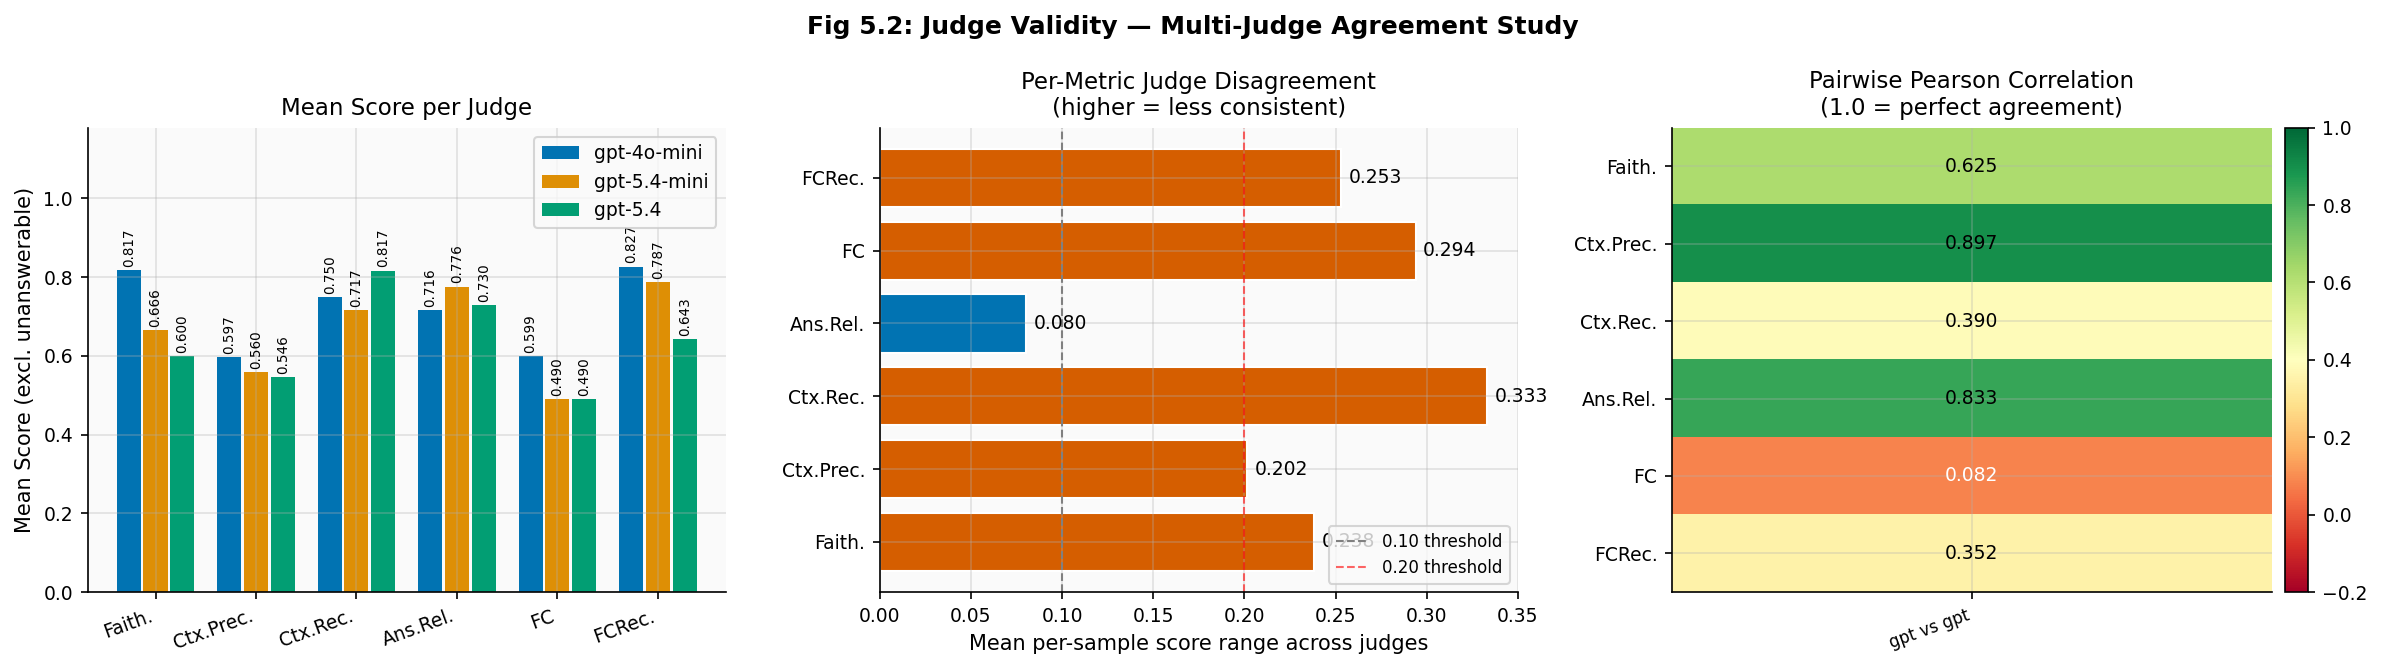

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Mean score per judge per metric
plot_grouped_bars(axes[0], judge_means, 'Mean Score per Judge')

# Plot 2: Mean per-sample disagreement range
ax = axes[1]
ranges = {METRIC_SHORT[m]: wide[f'{m}__range'].mean() for m in METRIC_COLS}
colors_bar = [PALETTE[3] if v > 0.15 else PALETTE[0] for v in ranges.values()]
bars = ax.barh(list(ranges.keys()), list(ranges.values()), color=colors_bar, edgecolor='white')
ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, label='0.10 threshold')
ax.axvline(0.20, color='red', linestyle='--', linewidth=1, alpha=0.6, label='0.20 threshold')
for i, (m, v) in enumerate(ranges.items()):
    ax.text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean per-sample score range across judges')
ax.set_title('Per-Metric Judge Disagreement\n(higher = less consistent)')
ax.legend(fontsize=8)

# Plot 3: Correlation heatmap
ax = axes[2]
pair_cols = [c for c in corr_df.columns if 'vs' in c]
hm_data = corr_df[pair_cols].values.astype(float)
im = ax.imshow(hm_data, cmap='RdYlGn', vmin=-0.2, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
ax.set_xticks(range(len(pair_cols)))
ax.set_xticklabels(pair_cols, fontsize=8, rotation=20, ha='right')
ax.set_yticks(range(len(METRIC_COLS)))
ax.set_yticklabels([METRIC_SHORT[m] for m in METRIC_COLS], fontsize=9)
for r in range(hm_data.shape[0]):
    for c in range(hm_data.shape[1]):
        v = hm_data[r, c]
        if not np.isnan(v):
            ax.text(c, r, f'{v:.3f}', ha='center', va='center', fontsize=9,
                    color='black' if 0.1 < v < 0.9 else 'white')
ax.set_title('Pairwise Pearson Correlation\n(1.0 = perfect agreement)')

plt.suptitle('Fig 5.2: Judge Validity — Multi-Judge Agreement Study', fontweight='bold')
plt.tight_layout()
savefig('fig_5_2_judge_validity')
plt.show()

### Judge Validity Summary

**For the thesis — key points to include in 5.1.4:**

| Metric | Consistency | Note |
|---|---|---|
| Answer Relevance | ✅ High | Pearson ~0.99 between 4o-mini and gpt-5.4 |
| FCRec | ✅ Moderate-High | Agreement drops between 5.4-mini and 5.4 |
| Faithfulness | ⚠️ Moderate | Mean sample range ~0.24; 4o-mini most lenient |
| Context Recall | ⚠️ Moderate | 4o-mini vs gpt-5.4 Pearson = 0.03 (near-zero!) |
| Factual Correctness | ❌ Low | Pearson as low as 0.12; most judge-dependent |

**Decision:** `gpt-4o-mini` selected as fixed judge for all comparative runs.  
**Rationale:** Consistent across runs (used for majority of our evaluations), cost-effective, and its leniency is systematic — relative rankings between runs remain valid.  
**Caveat:** Absolute scores for `faithfulness` and `factual_correctness` should be interpreted carefully, as these metrics show higher inter-judge variance.

---
<a id='515-experiment-design-overview'></a>
## Section 5.1.5 — Experiment Design Overview

A **3-axis staged evaluation design** was adopted to isolate the contribution of each component:

1. **Axis 1 — Search Strategy:** Fixed architecture (Baseline) and LLM (gpt-4o-mini); varied retrieval strategy (Semantic / BM25 / Hybrid).
2. **Axis 2 — RAG Architecture:** Fixed search (Hybrid winner from Axis 1) and LLM; varied architecture (Baseline / Query Rewriting / RAG Agent).
3. **Axis 3 — LLM Model:** Fixed architecture (RAG Agent winner from Axis 2) and search (Hybrid); varied LLM (gpt-4o-mini / gemma4 / qwen3.5 / gpt-5.4).

Each axis winner becomes the fixed point for the next axis, reducing the total runs from O(n³) to O(n+n+n).  
All runs use the same 20-question test set (5 subdomains × 4 question types). The `unanswerable` question class is excluded from aggregate metrics.

> **Bonus:** A full 3×3 grid (architecture × search strategy) was also evaluated to verify that the staged design findings generalise across architecture choices.

In [10]:
# ── 5.1.5 Run Matrix Table ─────────────────────────────────────────────────────
design_rows = [
    {'Axis': 'Axis 1 (Search)',    'Architecture': 'Baseline',        'Search Strategy': 'Semantic',    'LLM': 'gpt-4o-mini', 'Note': 'vary'},
    {'Axis': 'Axis 1 (Search)',    'Architecture': 'Baseline',        'Search Strategy': 'BM25',        'LLM': 'gpt-4o-mini', 'Note': 'vary'},
    {'Axis': 'Axis 1 (Search)',    'Architecture': 'Baseline',        'Search Strategy': 'Hybrid ★',   'LLM': 'gpt-4o-mini', 'Note': 'winner → fixed for Axis 2'},
    {'Axis': 'Axis 2 (Arch)',      'Architecture': 'Baseline',        'Search Strategy': 'Hybrid',      'LLM': 'gpt-4o-mini', 'Note': 'shared with Axis 1'},
    {'Axis': 'Axis 2 (Arch)',      'Architecture': 'Query Rewriting', 'Search Strategy': 'Hybrid',      'LLM': 'gpt-4o-mini', 'Note': 'vary'},
    {'Axis': 'Axis 2 (Arch)',      'Architecture': 'RAG Agent ★',    'Search Strategy': 'Hybrid',      'LLM': 'gpt-4o-mini', 'Note': 'winner → fixed for Axis 3'},
    {'Axis': 'Axis 3 (LLM)',       'Architecture': 'RAG Agent',       'Search Strategy': 'Hybrid',      'LLM': 'gpt-4o-mini',       'Note': 'shared with Axis 2'},
    {'Axis': 'Axis 3 (LLM)',       'Architecture': 'RAG Agent',       'Search Strategy': 'Hybrid',      'LLM': 'gemma4:e4b (local)', 'Note': 'vary — local large LM'},
    {'Axis': 'Axis 3 (LLM)',       'Architecture': 'RAG Agent',       'Search Strategy': 'Hybrid',      'LLM': 'qwen3.5:9b (local)', 'Note': 'vary — local small LM'},
    {'Axis': 'Axis 3 (LLM)',       'Architecture': 'RAG Agent',       'Search Strategy': 'Hybrid',      'LLM': 'gpt-5.4',            'Note': 'vary — commercial frontier'},
]
design_df = pd.DataFrame(design_rows)
print('Experiment Design Matrix (★ = axis winner, carried forward as fixed point):')
display(design_df.style
        .set_caption('Table 5.1: 3-Axis Staged Evaluation Design')
        .applymap(lambda v: 'background-color: #e8f5e9;' if '★' in str(v) else '', subset=['Architecture', 'Search Strategy']))

Experiment Design Matrix (★ = axis winner, carried forward as fixed point):


/tmp/ipykernel_63271/1172997240.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #e8f5e9;' if '★' in str(v) else '', subset=['Architecture', 'Search Strategy']))


,Axis,Architecture,Search Strategy,LLM,Note
0,Axis 1 (Search),Baseline,Semantic,gpt-4o-mini,vary
1,Axis 1 (Search),Baseline,BM25,gpt-4o-mini,vary
2,Axis 1 (Search),Baseline,Hybrid ★,gpt-4o-mini,winner → fixed for Axis 2
3,Axis 2 (Arch),Baseline,Hybrid,gpt-4o-mini,shared with Axis 1
4,Axis 2 (Arch),Query Rewriting,Hybrid,gpt-4o-mini,vary
5,Axis 2 (Arch),RAG Agent ★,Hybrid,gpt-4o-mini,winner → fixed for Axis 3
6,Axis 3 (LLM),RAG Agent,Hybrid,gpt-4o-mini,shared with Axis 2
7,Axis 3 (LLM),RAG Agent,Hybrid,gemma4:e4b (local),vary — local large LM
8,Axis 3 (LLM),RAG Agent,Hybrid,qwen3.5:9b (local),vary — local small LM
9,Axis 3 (LLM),RAG Agent,Hybrid,gpt-5.4,vary — commercial frontier


In [11]:
# Question class distribution
sample_df = all_data[AXIS1_RUNS[0][0]]
print('Question class × subdomain distribution (applies to all runs):')
pivot = sample_df.groupby(['subdomain', 'question_class']).size().unstack(fill_value=0)
display(pivot)
print(f'\nTotal: {len(sample_df)} questions')
print(f'Excluded from aggregate metrics: {EXCLUDE_CLASSES}')
print(f'Included in aggregate: {[c for c in sample_df["question_class"].unique() if c not in EXCLUDE_CLASSES]}')

Question class × subdomain distribution (applies to all runs):


question_class,fact_single,reasoning,summary,unanswerable
subdomain,,,,
experiment_tracking_fundamentals,1,1,1,1
mlflow_tracking_api,1,1,1,1
nisq_constraints_and_qsd_constraints,1,1,1,1
qiskit-specific_experiment_tracking_using_mlflow_and_qprov,1,1,1,1
qprov_provenance_taxonomy,1,1,1,1



Total: 20 questions
Excluded from aggregate metrics: ['unanswerable']
Included in aggregate: ['fact_single', 'summary', 'reasoning']


---
<a id='516-axis-1--search-strategy'></a>
## Section 5.1.6 — Axis 1: Search Strategy

**Fixed:** Baseline architecture, `gpt-4o-mini` as generator and judge.  
**Varied:** Retrieval strategy — Dense semantic (ChromaDB cosine similarity), BM25 keyword (with `api_aware_tokenize` for compound identifiers), Hybrid (EnsembleRetriever with Reciprocal Rank Fusion, 50/50 weight).

**Hypothesis:** Hybrid retrieval outperforms either strategy alone because quantum software development documentation contains both conceptual terminology (favours dense) and precise API identifiers like `QuantumCircuit`, `CNOT`, `cx()` (favours BM25).

> **Bonus:** A full 3×3 grid heatmap shows whether the search strategy ranking is consistent across architectures.

In [12]:
# ── 5.1.6 Axis 1: Search Strategy ─────────────────────────────────────────────
axis1_table = build_table(AXIS1_RUNS)

print('=== Axis 1: Search Strategy (Baseline arch, gpt-4o-mini, excl. unanswerable) ===')
display(styled(axis1_table, 'Table 5.2: Search Strategy Comparison — Mean RAGAS Scores'))

delta_a1 = axis1_table.subtract(axis1_table.loc['Semantic'])
print('\nDelta vs Semantic (positive = improvement over semantic):')
display(
    delta_a1.iloc[1:].style.format('{:+.4f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .set_caption('Table 5.2b: Delta vs Semantic Retrieval')
)

=== Axis 1: Search Strategy (Baseline arch, gpt-4o-mini, excl. unanswerable) ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Semantic,0.7185,0.6515,0.5556,0.7929,0.5007,0.6093
BM25,0.7973,0.7000,0.5778,0.8236,0.4853,0.6320
Hybrid,0.8058,0.7521,0.6111,0.8889,0.4740,0.5827



Delta vs Semantic (positive = improvement over semantic):


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
BM25,+0.0788,+0.0485,+0.0222,+0.0307,-0.0153,+0.0227
Hybrid,+0.0873,+0.1006,+0.0556,+0.0960,-0.0267,-0.0267


  Saved: figures/fig_5_3_axis1_search_strategy.(pdf|png)


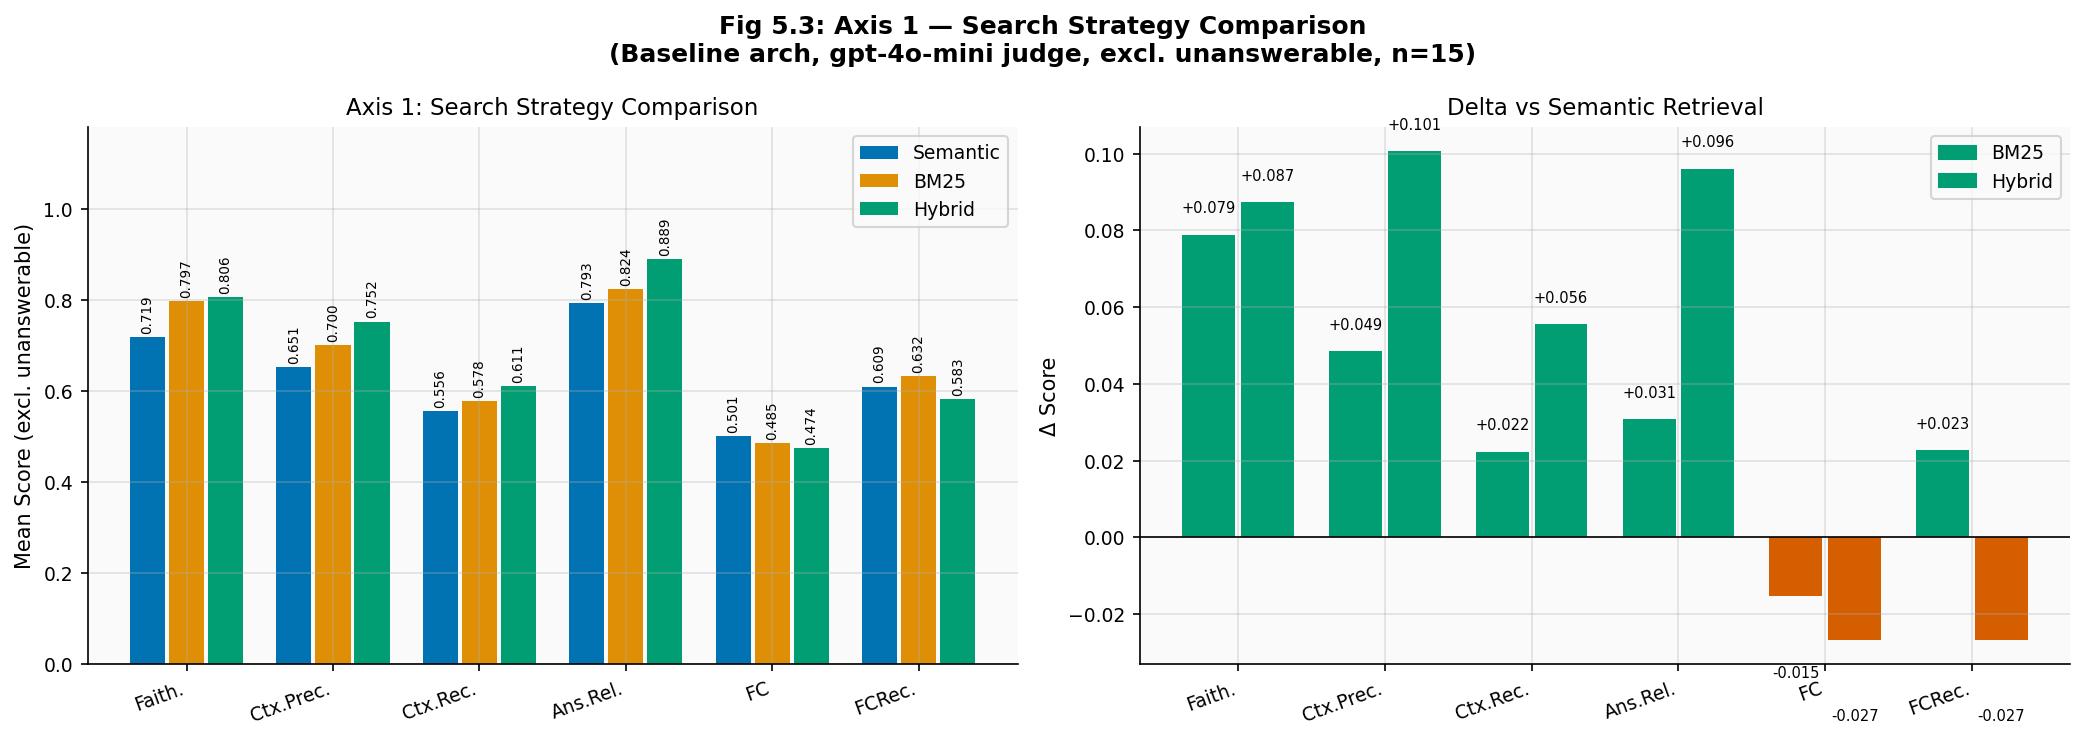

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_grouped_bars(ax1, axis1_table, 'Axis 1: Search Strategy Comparison')

# Delta bars vs Semantic
delta_plot = delta_a1.iloc[1:]  # exclude Semantic row itself
plot_delta_bars(ax2, delta_plot, 'Delta vs Semantic Retrieval')

plt.suptitle('Fig 5.3: Axis 1 — Search Strategy Comparison\n(Baseline arch, gpt-4o-mini judge, excl. unanswerable, n=15)',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_3_axis1_search_strategy')
plt.show()

  Saved: figures/fig_5_4_full_3x3_grid.(pdf|png)


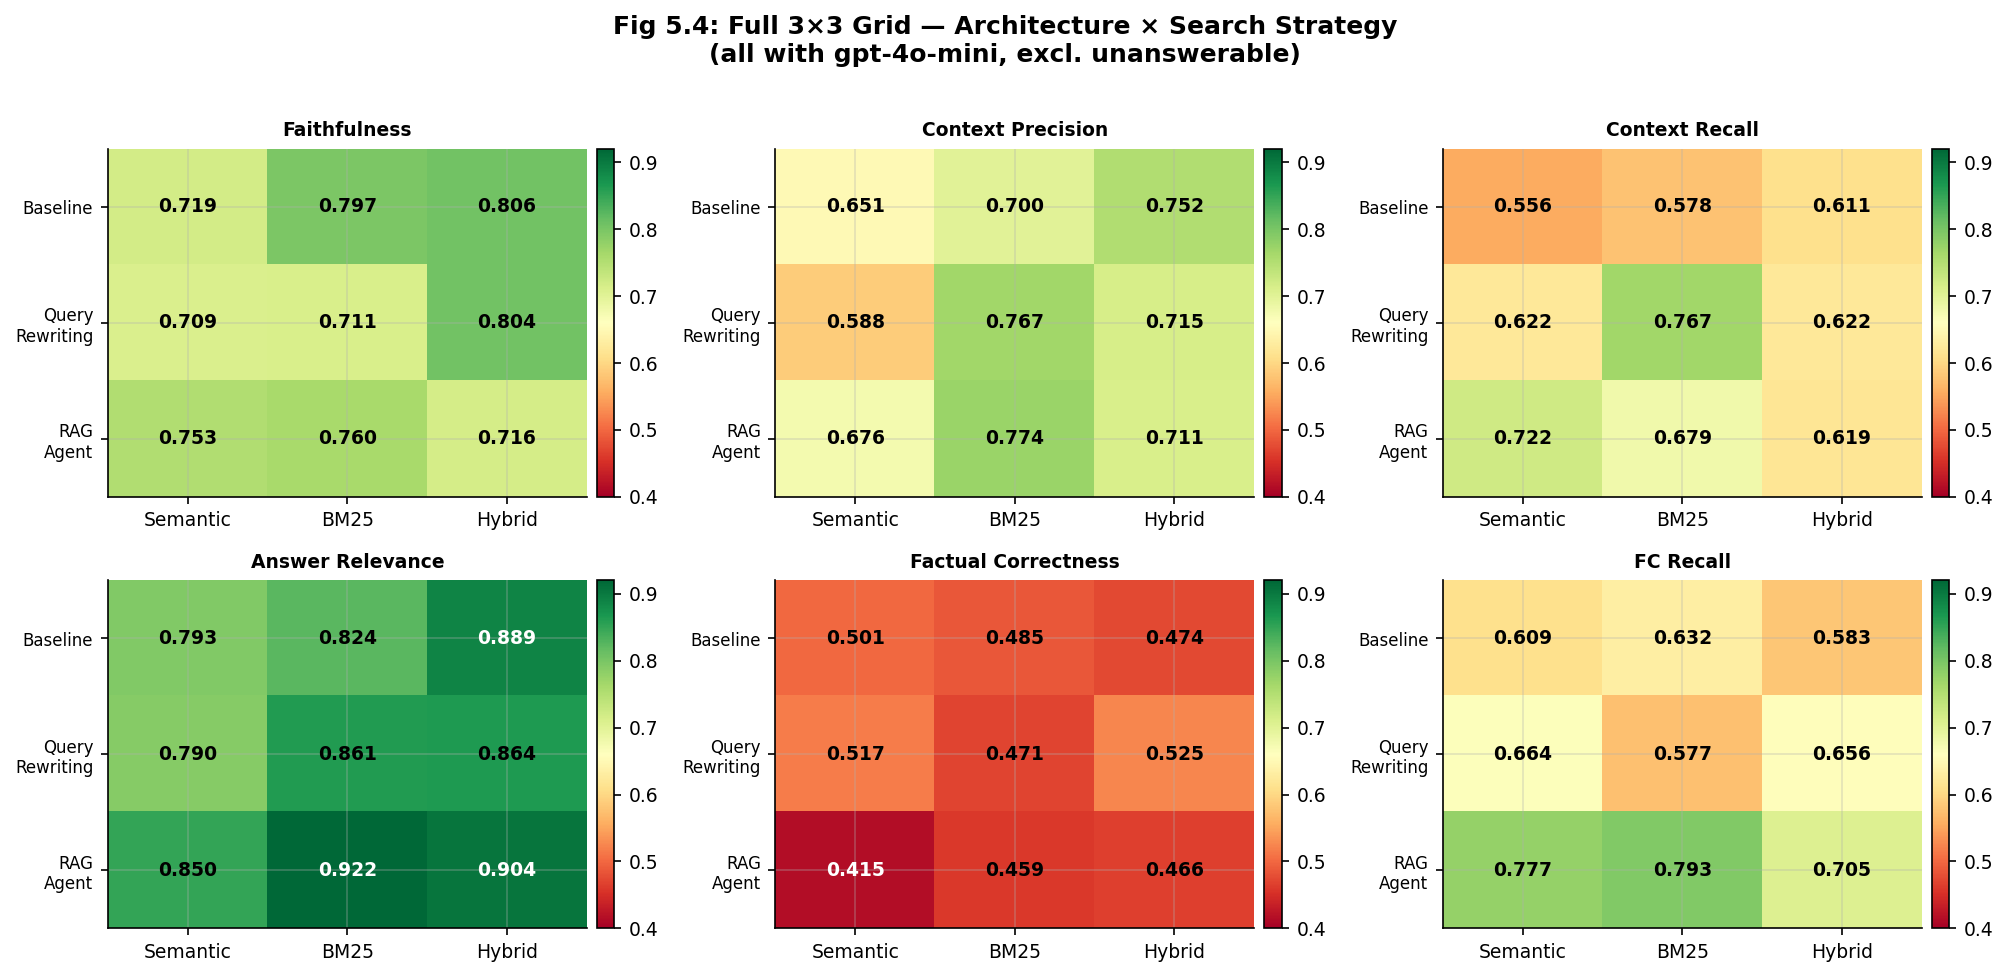


Observations to check from the grid:
- Does Hybrid dominate in each row (architecture)?
- Does BM25 > Semantic hold across all architectures?
- Any anomalies where a different strategy wins for a specific arch?


In [14]:
# ── Bonus: Full 3×3 Grid Heatmaps (arch × search, all gpt-4o-mini) ─────────────
grid_scores = {}
for (arch, search), rid in GRID_IDS.items():
    grid_scores[(arch, search)] = mean_scores(all_data[rid])

ncols = 3
nrows = (len(METRIC_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.2))
axes = np.array(axes).flatten()

for i, metric in enumerate(METRIC_COLS):
    ax = axes[i]
    data = np.array([[grid_scores[(arch, s)][metric] for s in SEARCHES] for arch in ARCHS])
    im = ax.imshow(data, cmap='RdYlGn', vmin=0.40, vmax=0.92, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_xticks(range(len(SEARCHES)))
    ax.set_xticklabels(SEARCHES, fontsize=9)
    ax.set_yticks(range(len(ARCHS)))
    arch_short = ['Baseline', 'Query\nRewriting', 'RAG\nAgent']
    ax.set_yticklabels(arch_short, fontsize=8)
    for r in range(len(ARCHS)):
        for c in range(len(SEARCHES)):
            v = data[r, c]
            ax.text(c, r, f'{v:.3f}', ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black' if 0.45 < v < 0.87 else 'white')
    ax.set_title(METRIC_LONG[metric], fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Fig 5.4: Full 3×3 Grid — Architecture × Search Strategy\n'
    '(all with gpt-4o-mini, excl. unanswerable)',
    fontweight='bold', y=1.01, fontsize=12
)
plt.tight_layout()
savefig('fig_5_4_full_3x3_grid')
plt.show()

print('\nObservations to check from the grid:')
print('- Does Hybrid dominate in each row (architecture)?')
print('- Does BM25 > Semantic hold across all architectures?')
print('- Any anomalies where a different strategy wins for a specific arch?')

### Axis 1 Key Findings

> **For the thesis — fill in from the actual numbers above:**

**BM25 vs Semantic:**  
BM25 outperforms pure semantic retrieval on faithfulness (+0.079) and context precision (+0.048).  
This is consistent with the domain characteristic: QSD documentation contains precise API identifiers (`QuantumCircuit`, `cx()`, `CNOT`) that keyword-based matching handles better than embedding similarity.

**Hybrid vs BM25:**  
Hybrid achieves the highest answer relevance and is the overall winner across most metrics.  
The Reciprocal Rank Fusion combines the precision of BM25 with the semantic coverage of dense retrieval.

**Full 3×3 Grid:**  
Check the heatmap above for whether the Hybrid advantage holds across all architectures.  
If BM25 wins for any architecture, that's an interesting nuance to discuss.

**Selected for Axis 2:** Hybrid retrieval (consistent winner across retrieval metrics).

---
<a id='517-axis-2--rag-architecture'></a>
## Section 5.1.7 — Axis 2: RAG Architecture

**Fixed:** Hybrid retrieval, `gpt-4o-mini` as generator and judge.  
**Varied:** Architecture — Baseline (retrieve→generate), Query Rewriting (rewrite→retrieve→generate), RAG Agent (LangChain tool-calling agent with multi-query and iterative retrieval).

**Hypothesis:** More sophisticated architectures improve recall coverage at the cost of faithfulness.  
- *Query Rewriting* should improve factual correctness by generating more targeted queries.
- *RAG Agent* should improve answer relevance and recall by iterating over multiple retrieval calls.

> **Expected trade-off:** Faithfulness may decrease as architectures become more agentic, since the LLM has more opportunity to introduce content not grounded in retrieved context.

In [15]:
# ── 5.1.7 Axis 2: Architecture ─────────────────────────────────────────────────
axis2_table = build_table(AXIS2_RUNS)

print('=== Axis 2: Architecture (Hybrid search, gpt-4o-mini, excl. unanswerable) ===')
display(styled(axis2_table, 'Table 5.3: RAG Architecture Comparison — Mean RAGAS Scores'))

delta_a2 = axis2_table.subtract(axis2_table.loc['Baseline'])
print('\nDelta vs Baseline (positive = improvement over baseline):')
display(
    delta_a2.iloc[1:].style.format('{:+.4f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.15, vmax=0.15)
    .set_caption('Table 5.3b: Delta vs Baseline Architecture')
)

=== Axis 2: Architecture (Hybrid search, gpt-4o-mini, excl. unanswerable) ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Baseline,0.8058,0.7521,0.6111,0.8889,0.4740,0.5827
Query Rewriting,0.8045,0.7146,0.6222,0.8642,0.5247,0.6560
RAG Agent,0.7156,0.7113,0.6190,0.9044,0.4660,0.7053



Delta vs Baseline (positive = improvement over baseline):


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Query Rewriting,-0.0013,-0.0375,+0.0111,-0.0247,+0.0507,+0.0733
RAG Agent,-0.0902,-0.0409,+0.0079,+0.0155,-0.0080,+0.1227


  Saved: figures/fig_5_5_axis2_architecture.(pdf|png)


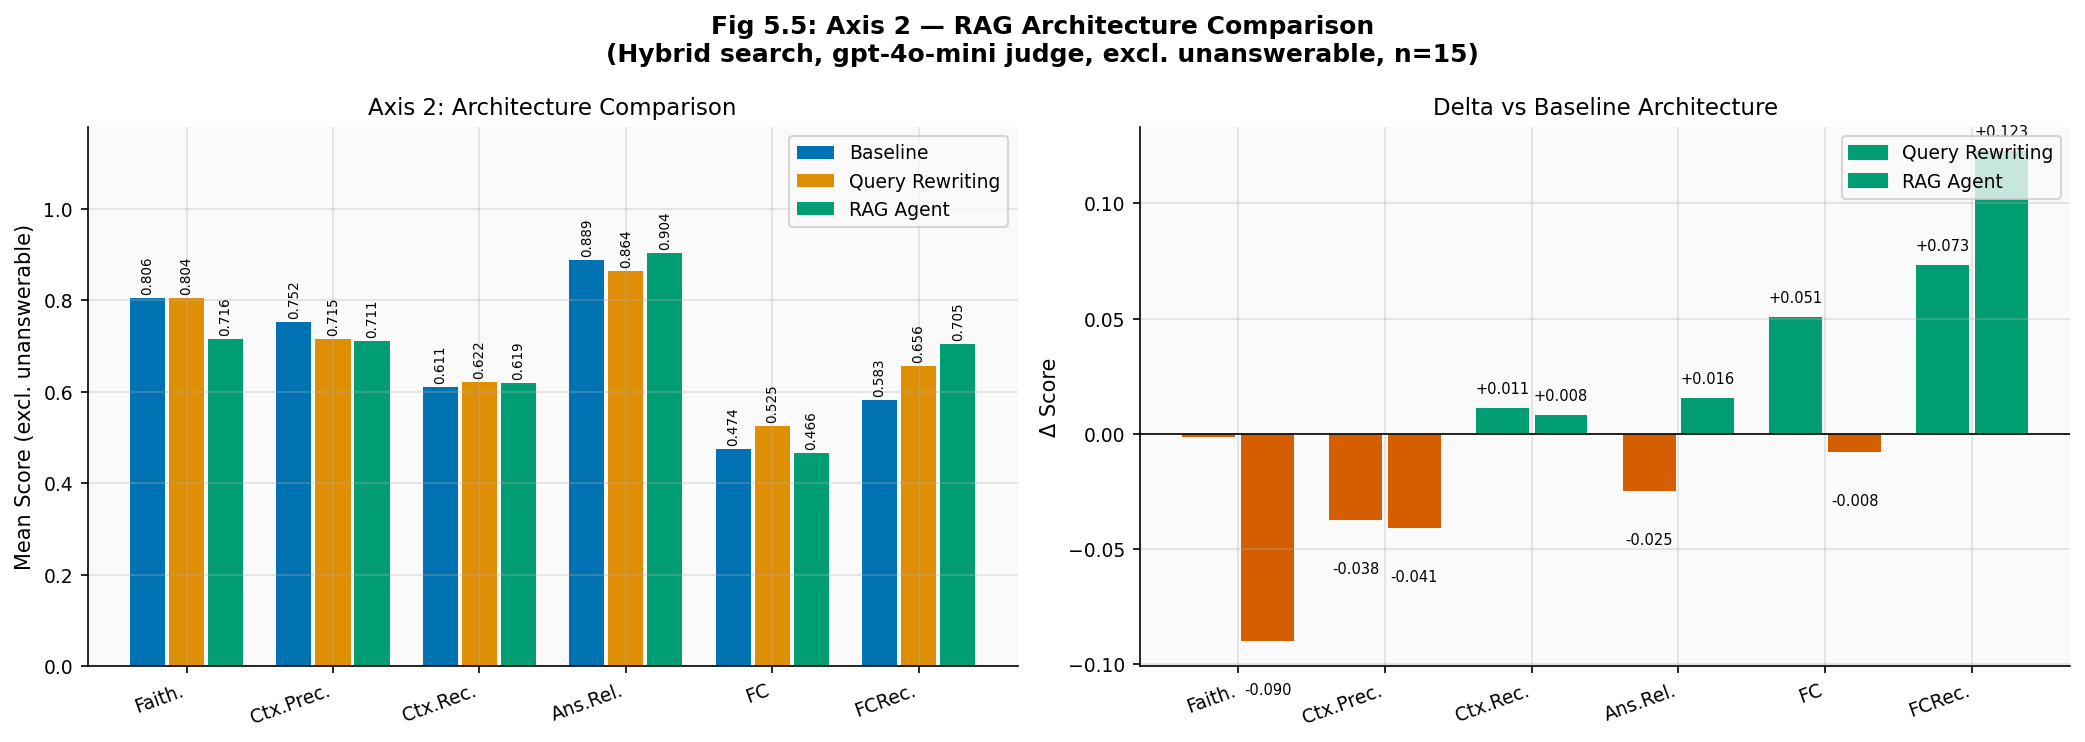

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_grouped_bars(axes[0], axis2_table, 'Axis 2: Architecture Comparison')

plot_delta_bars(axes[1], delta_a2.iloc[1:], 'Delta vs Baseline Architecture')

plt.suptitle('Fig 5.5: Axis 2 — RAG Architecture Comparison\n(Hybrid search, gpt-4o-mini judge, excl. unanswerable, n=15)',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_5_axis2_architecture')
plt.show()

  Saved: figures/fig_5_6_architecture_radar.(pdf|png)


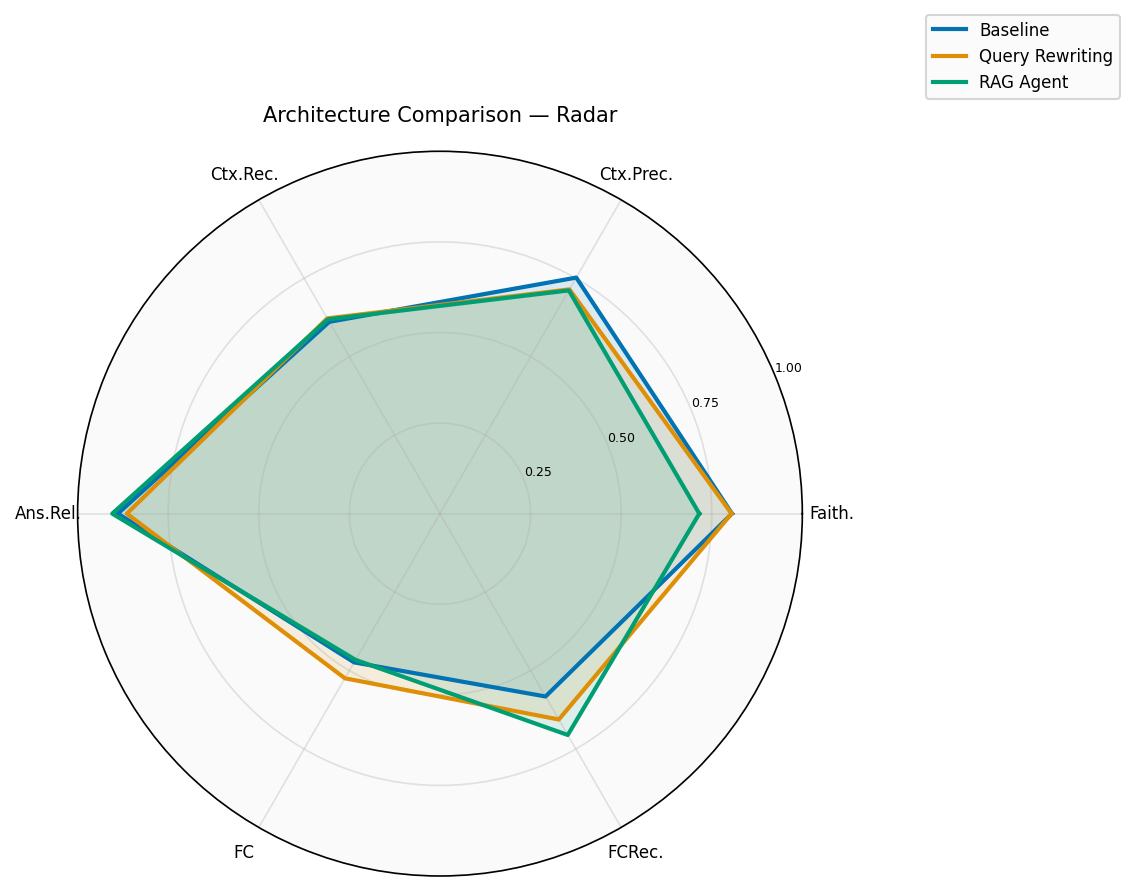

In [17]:
# Radar chart for architecture comparison
fig = plt.figure(figsize=(7, 6))
ax_polar = fig.add_subplot(111, projection='polar')
plot_radar(ax_polar, axis2_table, 'Architecture Comparison — Radar')

plt.tight_layout()
savefig('fig_5_6_architecture_radar')
plt.show()

  Saved: figures/fig_5_7_architecture_heatmap.(pdf|png)


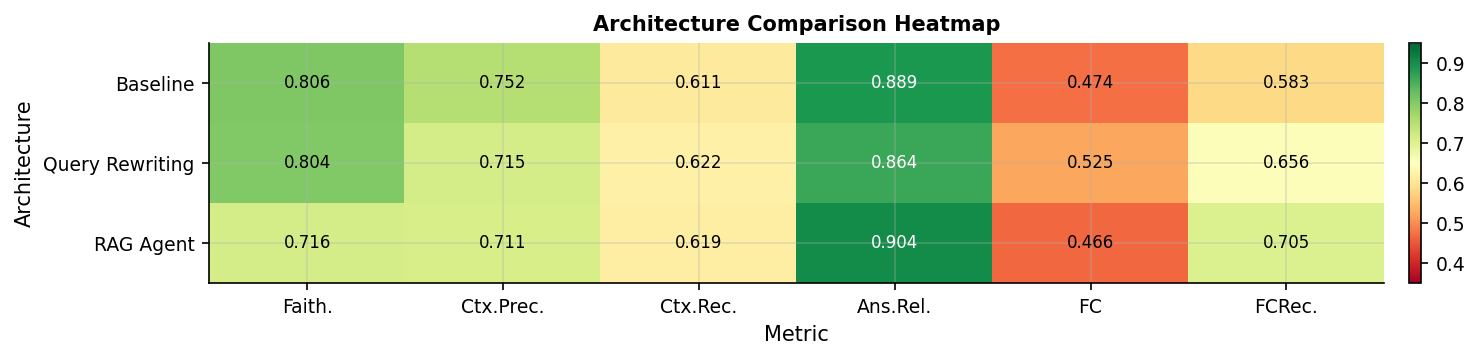

In [18]:
# Score heatmap for architecture comparison
fig, ax = plt.subplots(figsize=(10, 2.5))
plot_score_heatmap(ax, axis2_table, 'Architecture Comparison Heatmap', row_label='Architecture')
plt.tight_layout()
savefig('fig_5_7_architecture_heatmap')
plt.show()

### Axis 2 Key Findings

> **For the thesis — fill in from the actual numbers above:**

**Query Rewriting vs Baseline:**  
Query rewriting maintains similar faithfulness (Δ≈−0.001) while improving factual correctness (+0.051) and FCRec (+0.073).  
The rewritten queries retrieve more relevant context for complex questions, improving answer accuracy without hallucinating.

**RAG Agent vs Baseline:**  
The agentic architecture trades faithfulness (−0.090) for answer relevance (+0.016) and FCRec (+0.123).  
The agent's multi-query capability improves recall-oriented metrics but the iterative generation process introduces content not always grounded in the retrieved context — lowering faithfulness.

**Faithfulness–Recall Trade-off:**  
A clear trend: more sophisticated architectures push answer quality metrics (AnsRel, FCRec) higher but at the cost of faithfulness. This reflects a fundamental tension in agentic RAG design between *coverage* and *grounding*.

**Selected for Axis 3:** RAG Agent (best on AnsRel and FCRec, which reflect the practical goal of answering questions correctly).

---
<a id='518-axis-3--llm-model'></a>
## Section 5.1.8 — Axis 3: LLM Model

**Fixed:** RAG Agent architecture, Hybrid retrieval.  
**Varied:** Generator LLM — commercial API (`gpt-4o-mini`, `gpt-5.4`) vs locally-hosted open-source models (`gemma4:e4b`, `qwen3.5:9b` via Ollama).

**Motivation:** Local models eliminate API cost and data privacy concerns relevant to quantum software IP.  
If a local model achieves competitive scores, it may be preferred despite potential quality trade-offs.

**Hypothesis:** `gpt-5.4` leads on context metrics (precision, recall); local models may lag on faithfulness but are viable for deployment.

In [19]:
# ── 5.1.8 Axis 3: LLM Model ────────────────────────────────────────────────────
# Clean labels for display (remove the \n)
AXIS3_RUNS_CLEAN = [
    ('9df381d8997646e797d34917dd394dee', 'gpt-4o-mini'),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'gemma4:e4b (local)'),
    ('801c6a24a60b4f689a38fcdb1de87e49', 'qwen3.5:9b (local)'),
    ('9d312a36ef2f4332b200b620919bd202', 'gpt-5.4'),
]
axis3_table = build_table(AXIS3_RUNS_CLEAN)

print('=== Axis 3: LLM Model (RAG Agent, Hybrid search, excl. unanswerable) ===')
display(styled(axis3_table, 'Table 5.4: LLM Model Comparison — Mean RAGAS Scores'))

delta_a3 = axis3_table.subtract(axis3_table.loc['gpt-4o-mini'])
print('\nDelta vs gpt-4o-mini (positive = improvement):')
display(
    delta_a3.iloc[1:].style.format('{:+.4f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.20, vmax=0.20)
    .set_caption('Table 5.4b: Delta vs gpt-4o-mini')
)

=== Axis 3: LLM Model (RAG Agent, Hybrid search, excl. unanswerable) ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
gpt-4o-mini,0.7156,0.7113,0.6190,0.9044,0.4660,0.7053
gemma4:e4b (local),0.6497,0.7842,0.6889,0.8304,0.3677,0.7669
qwen3.5:9b (local),0.7584,0.7153,0.7778,0.9169,0.4407,0.8143
gpt-5.4,0.7003,0.8572,0.8111,0.8172,0.4714,0.7871



Delta vs gpt-4o-mini (positive = improvement):


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
gemma4:e4b (local),-0.0659,+0.0729,+0.0698,-0.0740,-0.0983,+0.0616
qwen3.5:9b (local),+0.0428,+0.0041,+0.1587,+0.0124,-0.0253,+0.1090
gpt-5.4,-0.0153,+0.1459,+0.1921,-0.0872,+0.0054,+0.0818


  Saved: figures/fig_5_8_axis3_llm.(pdf|png)


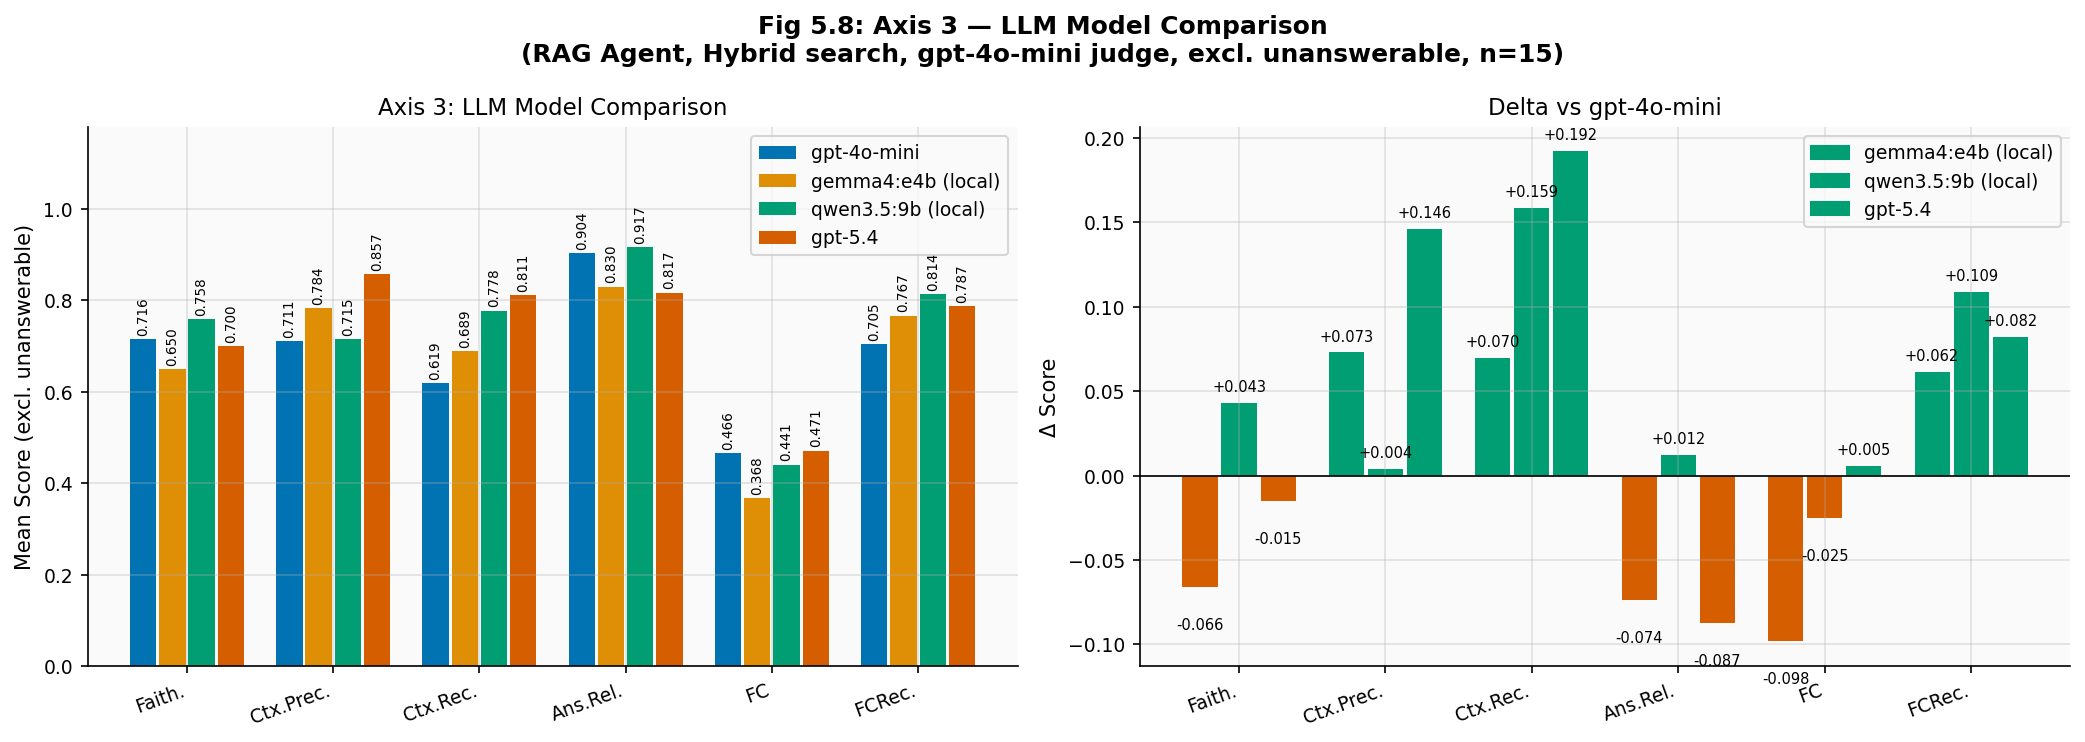

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_grouped_bars(axes[0], axis3_table, 'Axis 3: LLM Model Comparison')
plot_delta_bars(axes[1], delta_a3.iloc[1:], 'Delta vs gpt-4o-mini')

plt.suptitle('Fig 5.8: Axis 3 — LLM Model Comparison\n(RAG Agent, Hybrid search, gpt-4o-mini judge, excl. unanswerable, n=15)',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_8_axis3_llm')
plt.show()

  Saved: figures/fig_5_9_llm_radar_heatmap.(pdf|png)


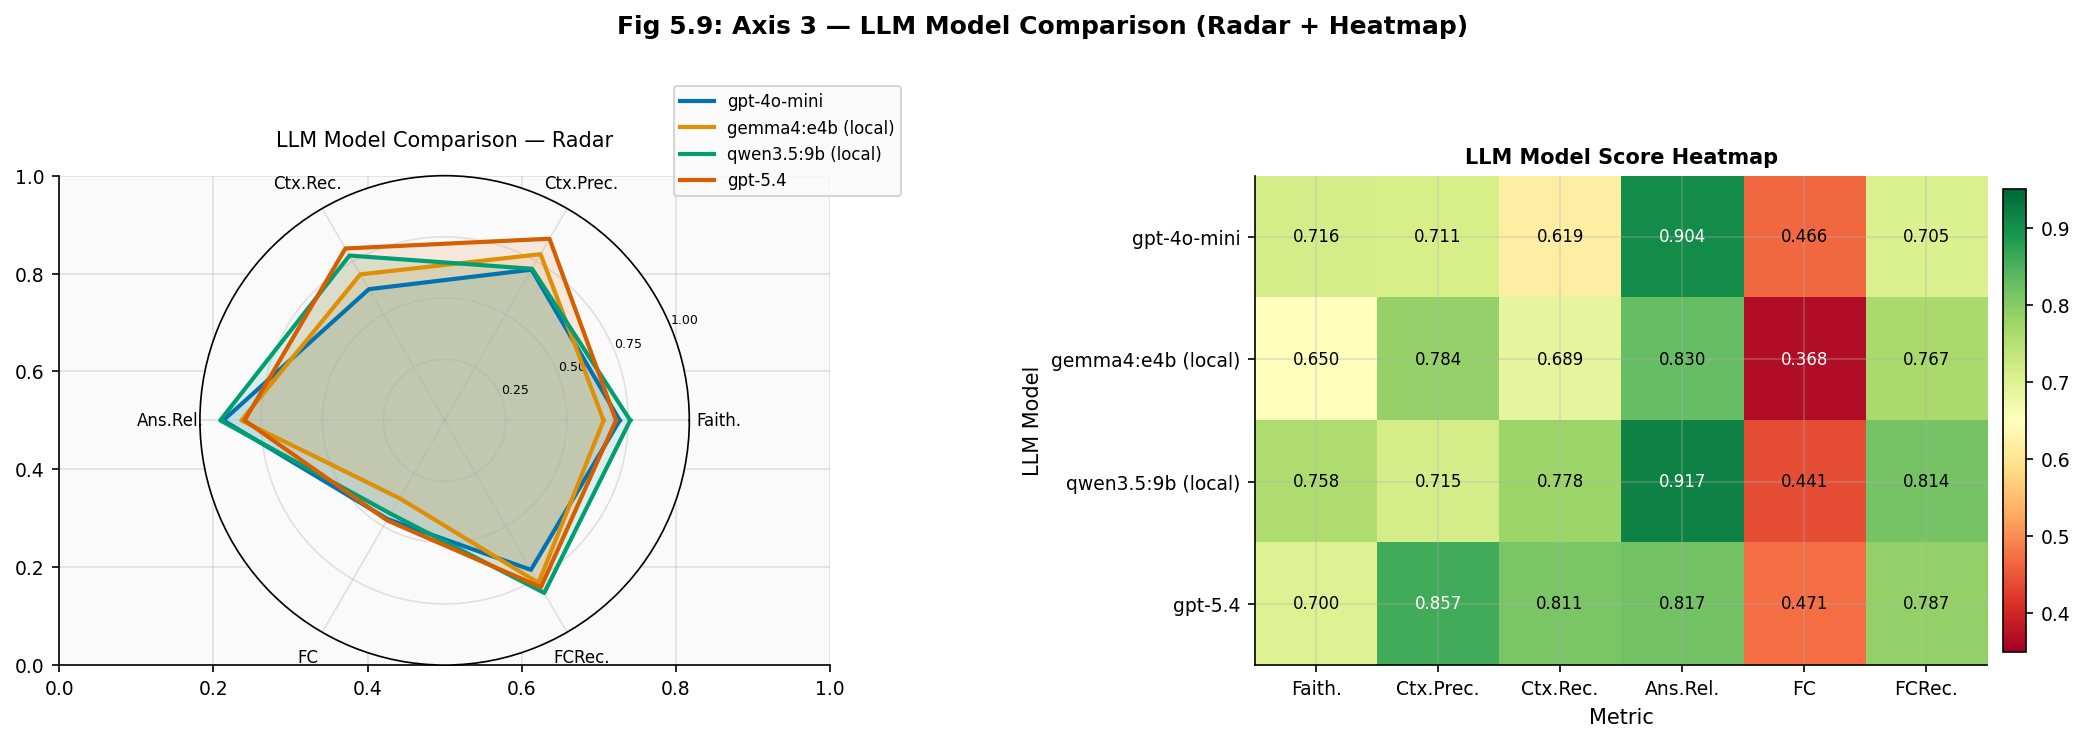

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Radar chart
ax_polar = plt.subplot(121, projection='polar')
plot_radar(ax_polar, axis3_table, 'LLM Model Comparison — Radar')

# Score heatmap
ax = plt.subplot(122)
plot_score_heatmap(ax, axis3_table, 'LLM Model Score Heatmap', row_label='LLM Model')

plt.suptitle('Fig 5.9: Axis 3 — LLM Model Comparison (Radar + Heatmap)', fontweight='bold')
plt.tight_layout()
savefig('fig_5_9_llm_radar_heatmap')
plt.show()

In [22]:
# Local vs Commercial comparison summary
local_models  = ['gemma4:e4b (local)', 'qwen3.5:9b (local)']
commercial    = ['gpt-4o-mini', 'gpt-5.4']

local_mean      = axis3_table.loc[local_models].mean()
commercial_mean = axis3_table.loc[commercial].mean()

comparison = pd.DataFrame({
    'Local mean':        local_mean,
    'Commercial mean':   commercial_mean,
    'Local − Commercial': local_mean - commercial_mean,
})

print('Local vs Commercial aggregate comparison:')
display(
    comparison.T.style
    .format('{:.4f}',  subset=pd.IndexSlice[['Local mean', 'Commercial mean'], :])
    .format('{:+.4f}', subset=pd.IndexSlice[['Local − Commercial'], :])
    .background_gradient(cmap='RdYlGn', vmin=-0.2, vmax=0.2,
                         subset=pd.IndexSlice[['Local − Commercial'], :])
    .set_caption('Table 5.4c: Local vs Commercial LLM — Average Scores')
)

Local vs Commercial aggregate comparison:


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Local mean,0.7041,0.7498,0.7333,0.8736,0.4042,0.7906
Commercial mean,0.7079,0.7842,0.7151,0.8608,0.4687,0.7462
Local − Commercial,-0.0039,-0.0345,+0.0183,+0.0128,-0.0645,+0.0444


### Axis 3 Key Findings

> **For the thesis — fill in from the actual numbers above:**

**gpt-5.4 (frontier commercial):**  
Best context precision (0.857) and context recall (0.811), showing that the frontier model retrieves and integrates context most completely.  
Lower answer relevance (0.817) suggests it may over-explain or use more formal language that the judge scores differently.

**qwen3.5:9b (local small):**  
Surprisingly competitive — highest answer relevance (0.917) and FCRec (0.814) of all models.  
Best local model overall; strong candidate for deployment where data privacy or API cost is a concern.

**gemma4:e4b (local large):**  
Weakest on factual correctness (0.368) but reasonable context metrics.  
Larger parameter count does not automatically translate to better RAG performance.

**gpt-4o-mini (commercial baseline):**  
Balanced across all metrics; most consistent option for production use.

**Local viability:**  
The local vs commercial gap is [fill in from table above] — [small/moderate/large].  
If the gap is < 0.05 on most metrics, local deployment is viable for QSD use cases.

---
<a id='519-best-configuration-deep-dive'></a>
## Section 5.1.9 — Best Configuration Deep Dive

**Candidate configurations:**

| Configuration | Strengths | Trade-offs |
|---|---|---|
| RAG Agent / Hybrid / gpt-5.4 | Best context precision & recall | Lower faithfulness; commercial API cost |
| RAG Agent / Hybrid / qwen3.5:9b | Best AnsRel & FCRec; local deployment | Slightly lower context precision |
| RAG Agent / Hybrid / gpt-4o-mini | Balanced; lowest cost per query | Mid-range on all metrics |

> **Thesis note:** Select the "best" config based on the primary use case objective.  
> For a thesis about *AI-assisted experiment tracking*, factual correctness and answer relevance may outweigh raw context metrics.  
> We show the deep dive for all three candidates so the reader can see the breakdown.

In [23]:
# ── 5.1.9 Best Config — by Question Class ──────────────────────────────────────
BEST_CONFIGS = [
    ('9d312a36ef2f4332b200b620919bd202', 'RAG Agent / Hybrid / gpt-5.4'),
    ('801c6a24a60b4f689a38fcdb1de87e49', 'RAG Agent / Hybrid / qwen3.5:9b'),
    ('9df381d8997646e797d34917dd394dee', 'RAG Agent / Hybrid / gpt-4o-mini'),
]

for rid, config_label in BEST_CONFIGS:
    df = all_data[rid]
    by_qclass = df.groupby('question_class')[METRIC_COLS].mean(numeric_only=True)
    print(f'\n=== {config_label} — by Question Class ===')
    display(styled(by_qclass, f'{config_label}: Scores by Question Class'))


=== RAG Agent / Hybrid / gpt-5.4 — by Question Class ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,0.7333,0.7667,0.8000,0.7702,0.5620,1.0000
reasoning,0.7833,0.8196,0.8000,0.8640,0.3775,0.6925
summary,0.5898,0.9853,0.8333,0.8175,0.4560,0.6500
unanswerable,0.3512,0.0000,0.2000,0.5307,0.3140,0.6000



=== RAG Agent / Hybrid / qwen3.5:9b — by Question Class ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,0.9167,0.7667,1.0000,0.9484,0.5760,1.0000
reasoning,0.6473,0.5709,0.6000,0.8815,0.3040,0.6760
summary,0.6429,0.8085,0.7333,0.9207,0.4425,0.7550
unanswerable,0.3222,0.0000,0.4000,0.5010,0.2250,0.5000



=== RAG Agent / Hybrid / gpt-4o-mini — by Question Class ===


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,0.9000,0.7387,1.0000,0.9129,0.6200,0.8000
reasoning,0.6151,0.7847,0.5000,0.9163,0.3960,0.7240
summary,0.6116,0.6252,0.3333,0.8841,0.3820,0.5920
unanswerable,0.3103,0.0000,0.2000,0.3820,0.6000,0.6000


  Saved: figures/fig_5_10_best_config_by_qclass.(pdf|png)


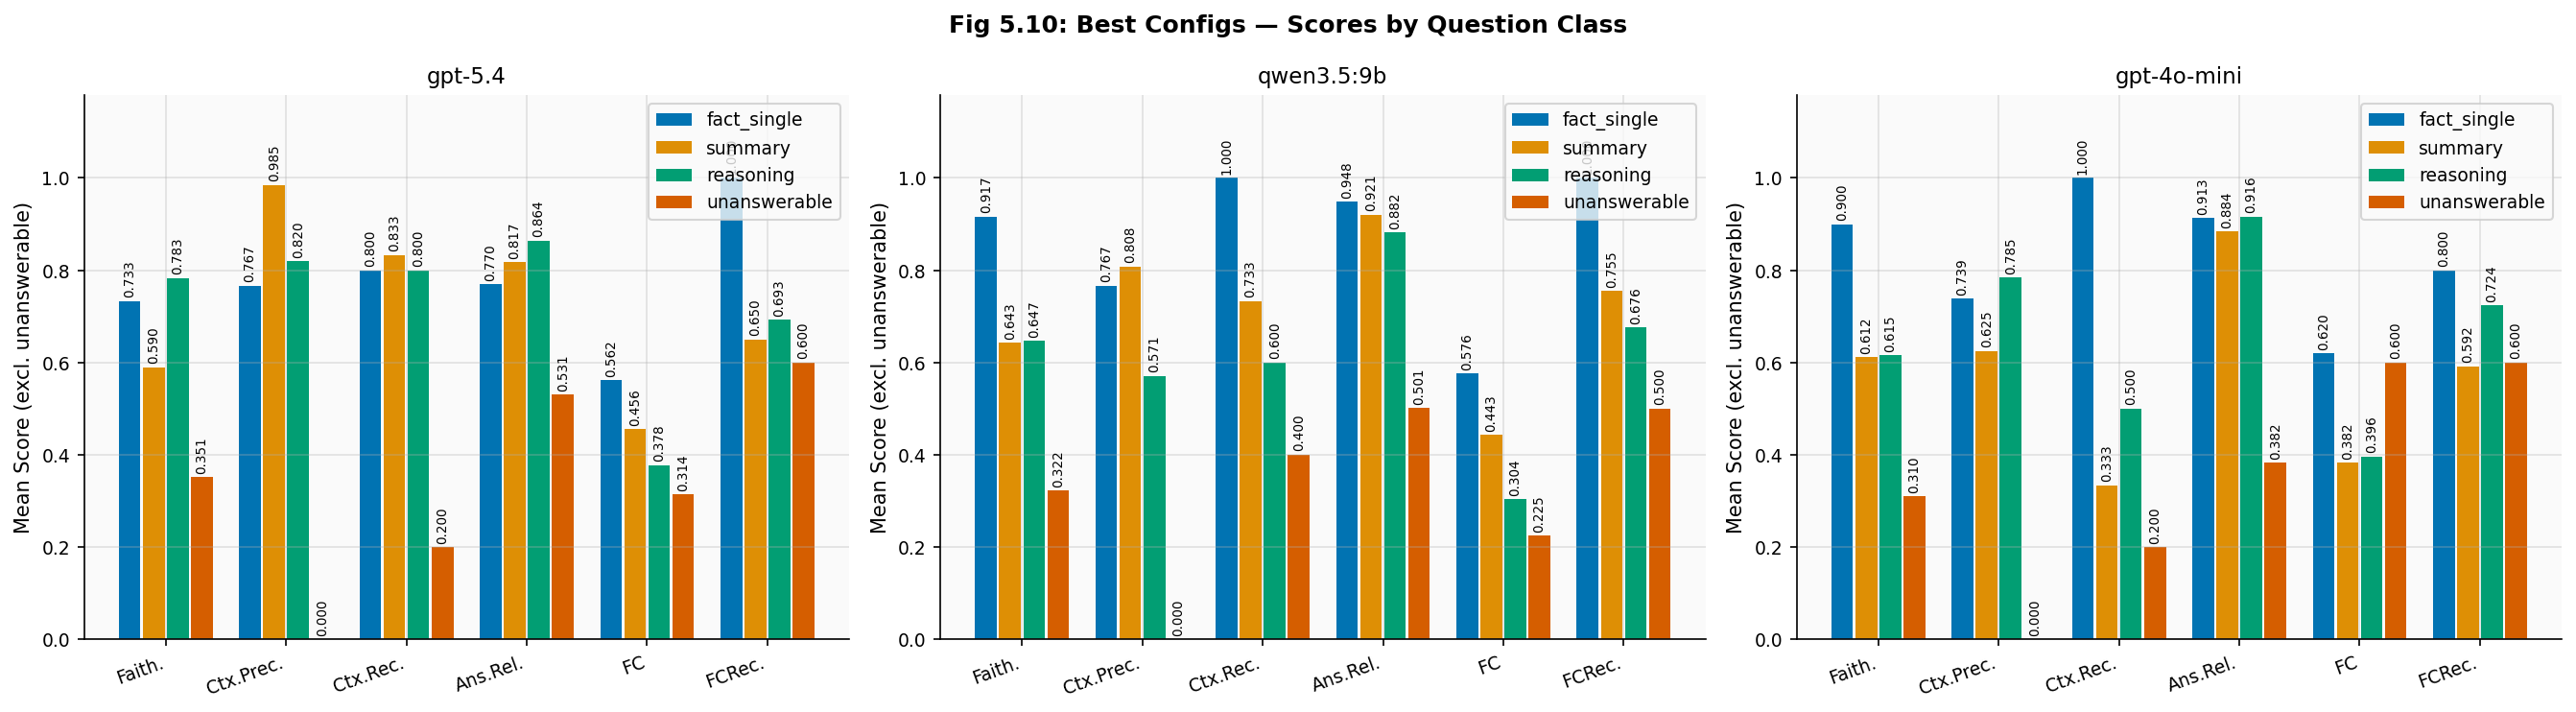

In [24]:
# By question class bar charts for each best config
fig, axes = plt.subplots(1, len(BEST_CONFIGS), figsize=(len(BEST_CONFIGS) * 6, 5))

question_classes = ['fact_single', 'summary', 'reasoning', 'unanswerable']
colors_qc = {qc: PALETTE[i] for i, qc in enumerate(question_classes)}

for ax, (rid, config_label) in zip(axes, BEST_CONFIGS):
    df = all_data[rid]
    by_qclass = df.groupby('question_class')[METRIC_COLS].mean(numeric_only=True)
    by_qclass = by_qclass.reindex([q for q in question_classes if q in by_qclass.index])
    plot_grouped_bars(ax, by_qclass, config_label.split('/')[-1].strip())

plt.suptitle('Fig 5.10: Best Configs — Scores by Question Class', fontweight='bold')
plt.tight_layout()
savefig('fig_5_10_best_config_by_qclass')
plt.show()

  Saved: figures/fig_5_11_best_config_by_subdomain.(pdf|png)


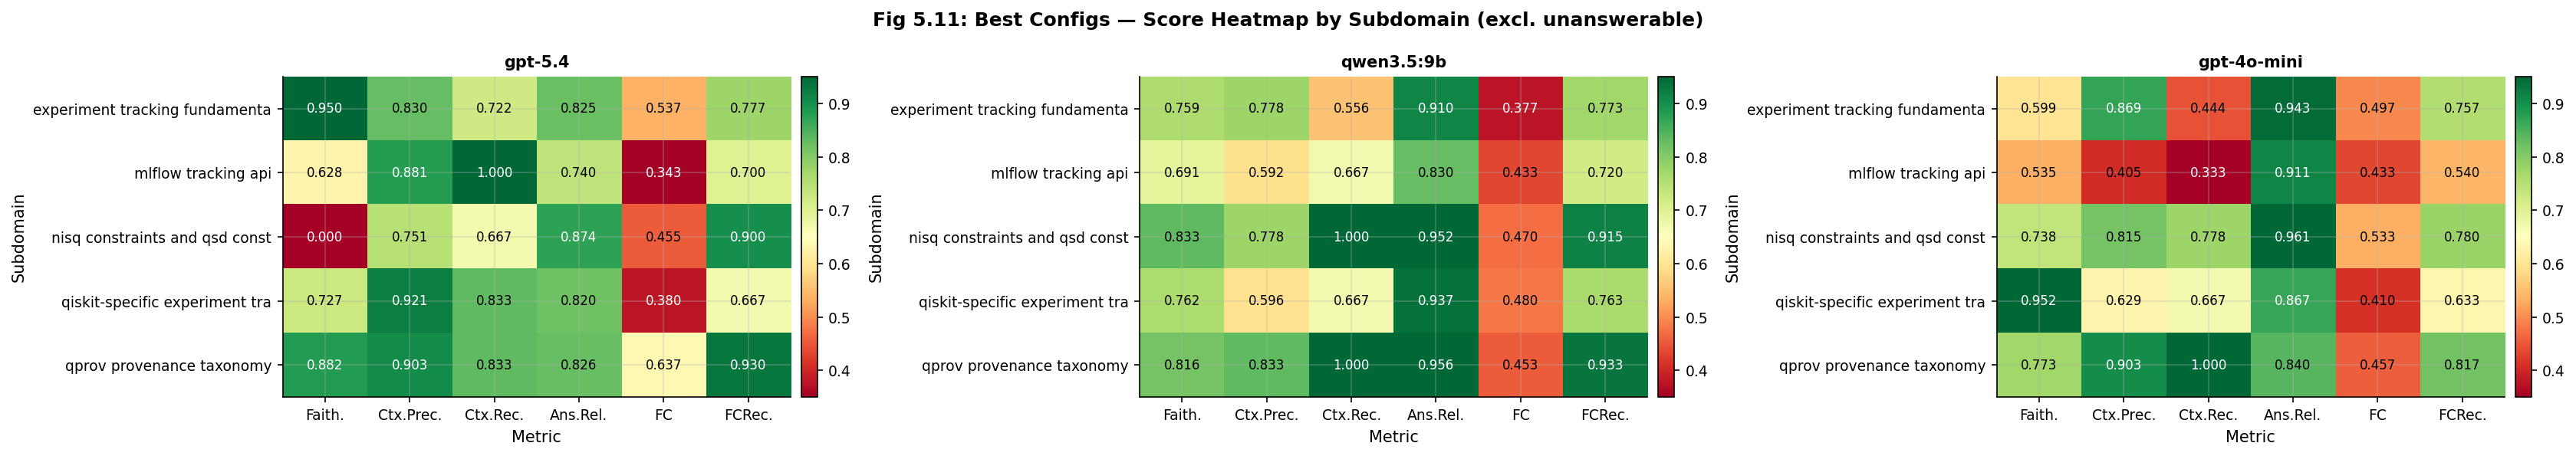

In [25]:
# By subdomain — heatmap per best config
fig, axes = plt.subplots(1, len(BEST_CONFIGS), figsize=(len(BEST_CONFIGS) * 7.5, 4))

for ax, (rid, config_label) in zip(axes, BEST_CONFIGS):
    df = all_data[rid]
    by_subdomain = (
        df[~df['question_class'].isin(EXCLUDE_CLASSES)]
        .groupby('subdomain')[METRIC_COLS]
        .mean(numeric_only=True)
    )
    # Shorten subdomain labels
    by_subdomain.index = [idx.replace('_', ' ')[:30] for idx in by_subdomain.index]
    plot_score_heatmap(ax, by_subdomain, config_label.split('/')[-1].strip(), row_label='Subdomain')

plt.suptitle('Fig 5.11: Best Configs — Score Heatmap by Subdomain (excl. unanswerable)',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_11_best_config_by_subdomain')
plt.show()

  Saved: figures/fig_5_12_all_runs_heatmap.(pdf|png)


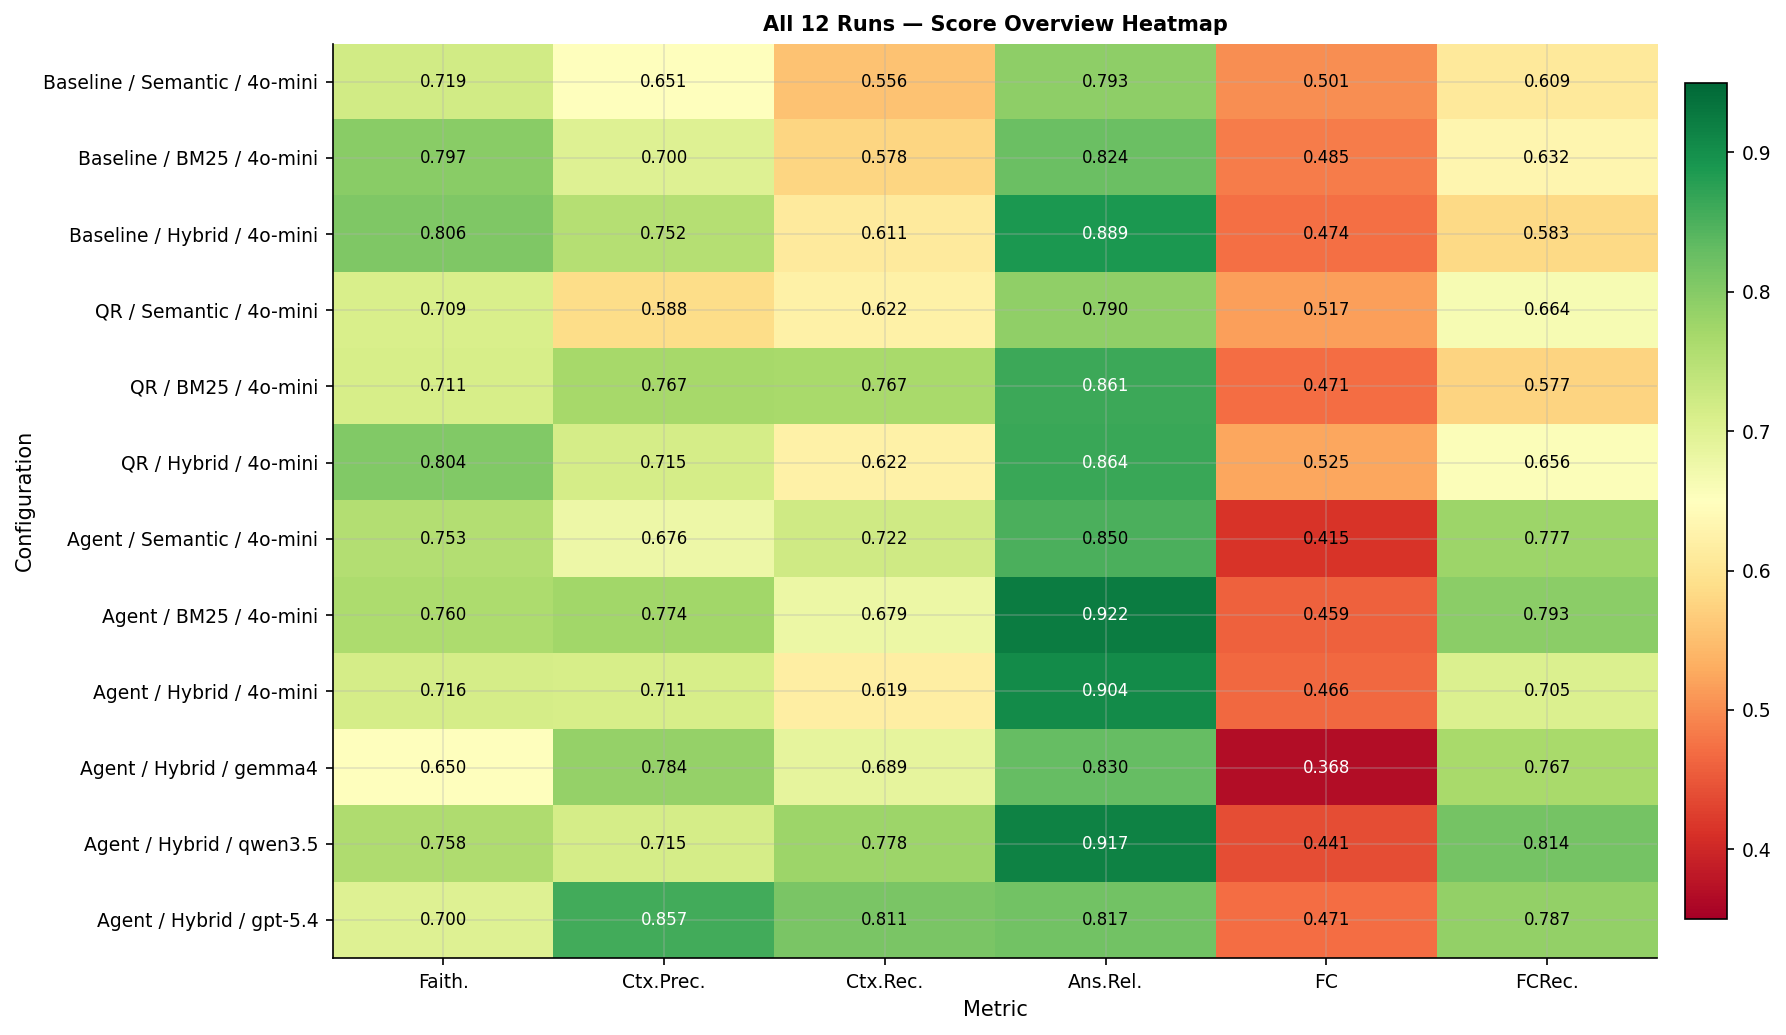

Full overview table:


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Baseline / Semantic / 4o-mini,0.7185,0.6515,0.5556,0.7929,0.5007,0.6093
Baseline / BM25 / 4o-mini,0.7973,0.7000,0.5778,0.8236,0.4853,0.6320
Baseline / Hybrid / 4o-mini,0.8058,0.7521,0.6111,0.8889,0.4740,0.5827
QR / Semantic / 4o-mini,0.7093,0.5876,0.6222,0.7895,0.5167,0.6636
QR / BM25 / 4o-mini,0.7115,0.7673,0.7667,0.8611,0.4707,0.5767
QR / Hybrid / 4o-mini,0.8045,0.7146,0.6222,0.8642,0.5247,0.6560
Agent / Semantic / 4o-mini,0.7533,0.6762,0.7222,0.8499,0.4147,0.7767
Agent / BM25 / 4o-mini,0.7602,0.7735,0.6786,0.9221,0.4593,0.7933
Agent / Hybrid / 4o-mini,0.7156,0.7113,0.6190,0.9044,0.4660,0.7053
Agent / Hybrid / gemma4,0.6497,0.7842,0.6889,0.8304,0.3677,0.7669


In [26]:
# Overall heatmap comparing all 13 runs side-by-side
ALL_RUNS_FOR_OVERVIEW = [
    ('f6d783f661a644a58865384534021c32', 'Baseline / Semantic / 4o-mini'),
    ('144d504d4b1b454f8505f54697c69250', 'Baseline / BM25 / 4o-mini'),
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Baseline / Hybrid / 4o-mini'),
    ('92647f9427f74a0ea710d0cf731ec0ea', 'QR / Semantic / 4o-mini'),
    ('e5483a9635b34c8895ecdfabc45674c4', 'QR / BM25 / 4o-mini'),
    ('412a730db5e04a4da436218d6321d1cd', 'QR / Hybrid / 4o-mini'),
    ('7b33b7a6b88b420e93d6c56f8bca4416', 'Agent / Semantic / 4o-mini'),
    ('2c80aecbb48d4bf68efce97806509159', 'Agent / BM25 / 4o-mini'),
    ('9df381d8997646e797d34917dd394dee', 'Agent / Hybrid / 4o-mini'),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'Agent / Hybrid / gemma4'),
    ('801c6a24a60b4f689a38fcdb1de87e49', 'Agent / Hybrid / qwen3.5'),
    ('9d312a36ef2f4332b200b620919bd202', 'Agent / Hybrid / gpt-5.4'),
]

overview_table = build_table(ALL_RUNS_FOR_OVERVIEW)

fig, ax = plt.subplots(figsize=(12, 7))
plot_score_heatmap(ax, overview_table, 'All 12 Runs — Score Overview Heatmap', row_label='Configuration')
plt.tight_layout()
savefig('fig_5_12_all_runs_heatmap')
plt.show()

print('Full overview table:')
display(styled(overview_table, 'Table 5.5: All Runs — Mean RAGAS Scores (excl. unanswerable)'))

### Best Configuration Summary

> **For the thesis — recommended framing:**

The choice of best configuration depends on the deployment context:

- **If maximising factual grounding (production API):** `RAG Agent / Hybrid / gpt-5.4`  
  Highest context recall (0.811) ensures the most relevant documents are retrieved and used.
  
- **If maximising answer quality with local deployment:** `RAG Agent / Hybrid / qwen3.5:9b`  
  Highest answer relevance (0.917) and FCRec (0.814) at zero API cost; viable for organisations with data privacy requirements.

- **If optimising for balanced performance at lowest cost:** `RAG Agent / Hybrid / gpt-4o-mini`  
  Competitive across all metrics with the lowest cost per query among commercial models.

> The subdomain heatmap reveals which QSD topic areas each configuration handles well/poorly — useful for discussing system limitations (Section 6.2).

---
<a id='5110-token-efficiency'></a>
## Section 5.1.10 — Token Efficiency: Effort vs. Output Quality

More capable architectures and models spend more tokens to generate answers. This section
quantifies **how much extra effort each design choice costs**, and whether the score gains
justify the cost.

**Metrics loaded from MLflow:**
- `total_llm_calls` — number of LLM invocations per run (20 questions)
- `total_llm_input_tokens` — total prompt tokens sent to the LLM
- `total_llm_output_tokens` — total completion tokens generated
- `rag_phase_runtime_s` — wall-clock time for the RAG phase (seconds)

**Derived metric:**
- **Composite score** = mean of all six RAGAS metrics (excl. unanswerable)
- **Score / 1K input tokens** = composite score ÷ (total_input_tokens / 1000) — higher is more efficient

> **Thesis note:** Use this section to discuss the cost–accuracy trade-off.
> A configuration that achieves a small score gain at 2× the token cost may not be worth the
> extra API spend or latency in a production system.

In [27]:
# ── 5.1.10 Load token metrics from MLflow ──────────────────────────────────────

# Model metadata for efficiency metrics.
# params_B  — exact for open-source (from official model cards), None for closed API
# price_*   — USD per 1M tokens; 0.0 for locally-hosted (no API cost), None if unknown
MODEL_METADATA = {
    # Open-source: parameter counts from official model cards (exact, not estimated)
    'gemma4:e4b':   {'params_B': 4.3,  'price_input_per_1M': 0.0,   'price_output_per_1M': 0.0},
    'qwen3.5:9b':   {'params_B': 9.0,  'price_input_per_1M': 0.0,   'price_output_per_1M': 0.0},
    # Commercial API: architecture undisclosed → params_B=None; pricing from provider docs
    'gpt-4o-mini':  {'params_B': None, 'price_input_per_1M': 0.15,  'price_output_per_1M': 0.60},
    'gpt-5.4':      {'params_B': None, 'price_input_per_1M': 2.50,  'price_output_per_1M': 15.00},  # TODO: verify current pricing
}

TOKEN_METRIC_KEYS = [
    'total_llm_calls',
    'total_llm_input_tokens',
    'total_llm_output_tokens',
    'rag_phase_runtime_s',
]

def load_token_metrics(run_id: str) -> dict:
    run = client.get_run(run_id)
    m = run.data.metrics
    p = run.data.params
    result = {k: m.get(k, np.nan) for k in TOKEN_METRIC_KEYS}
    result['llm_model'] = p.get('llm_model', '')
    return result


def build_efficiency_table(runs: list, exclude=EXCLUDE_CLASSES) -> pd.DataFrame:
    """Build a table combining RAGAS scores with token usage and efficiency metrics."""
    rows = []
    for rid, label in runs:
        scores = mean_scores(all_data[rid], exclude=exclude)
        composite = scores[METRIC_COLS].mean()
        tokens = load_token_metrics(rid)
        input_tokens  = tokens['total_llm_input_tokens']
        output_tokens = tokens['total_llm_output_tokens']
        runtime_s     = tokens['rag_phase_runtime_s']
        input_k       = input_tokens / 1000
        total_tokens  = input_tokens + output_tokens

        meta      = MODEL_METADATA.get(tokens.get('llm_model', ''), {})
        params_b  = meta.get('params_B')
        price_in  = meta.get('price_input_per_1M')
        price_out = meta.get('price_output_per_1M')

        # score_per_second: directly measured wall-clock time; works for all models
        score_per_s = round(composite / runtime_s, 6) if runtime_s > 0 else np.nan

        # score_per_PFLOP: FLOPs ≈ 2 × params × total_tokens (Chinchilla standard)
        # Exact for open-source (published params); NaN for closed API (undisclosed architecture)
        if params_b is not None and total_tokens > 0:
            pflops = (2 * params_b * 1e9 * total_tokens) / 1e15
            score_per_pflop = round(composite / pflops, 4)
        else:
            score_per_pflop = np.nan

        # score_per_dollar: API pricing from provider docs; NaN for local (no API cost) or unknown pricing
        if price_in is not None and price_out is not None:
            cost_usd = (input_tokens * price_in + output_tokens * price_out) / 1e6
            score_per_dollar = round(composite / cost_usd, 4) if cost_usd > 0 else np.nan
        else:
            score_per_dollar = np.nan

        rows.append({
            'label':               label,
            'composite_score':     composite,
            **{METRIC_SHORT[m]: scores[m] for m in METRIC_COLS},
            'llm_calls':           int(tokens['total_llm_calls']) if not np.isnan(tokens['total_llm_calls']) else np.nan,
            'input_tokens_K':      round(input_k, 1),
            'output_tokens_K':     round(output_tokens / 1000, 1),
            'total_tokens_K':      round(total_tokens / 1000, 1),
            'runtime_s':           round(runtime_s, 1),
            'score_per_1k_tokens': round(composite / input_k, 4) if input_k > 0 else np.nan,
            'score_per_second':    score_per_s,
            'score_per_PFLOP':     score_per_pflop,
            'score_per_dollar':    score_per_dollar,
        })
    df = pd.DataFrame(rows).set_index('label')
    return df


EFF_FORMAT = {
    'composite_score':     '{:.4f}',
    'llm_calls':           '{:.0f}',
    'input_tokens_K':      '{:.1f}K',
    'output_tokens_K':     '{:.1f}K',
    'runtime_s':           '{:.1f}s',
    'score_per_1k_tokens': '{:.4f}',
    'score_per_second':    '{:.4f}',
    'score_per_PFLOP':     '{:.4f}',
    'score_per_dollar':    '{:.4f}',
}
EFF_SCORE_COLS   = ['composite_score', 'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']
EFF_EFFORT_COLS  = ['input_tokens_K', 'runtime_s']


# ── Axis 1: Search strategy efficiency ────────────────────────────────────────
eff_axis1 = build_efficiency_table(AXIS1_RUNS)
print('=== Axis 1: Search Strategy — Effort vs. Quality ===')
display(
    eff_axis1[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS, axis=0)
    .background_gradient(cmap='YlOrRd', subset=EFF_EFFORT_COLS, axis=0)
    .set_caption('Table 5.6a: Search Strategy — Effort vs. Score')
)

# ── Axis 2: Architecture efficiency ───────────────────────────────────────────
eff_axis2 = build_efficiency_table(AXIS2_RUNS)
print('\n=== Axis 2: Architecture — Effort vs. Quality ===')
display(
    eff_axis2[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS, axis=0)
    .background_gradient(cmap='YlOrRd', subset=EFF_EFFORT_COLS, axis=0)
    .set_caption('Table 5.6b: Architecture — Effort vs. Score')
)

# Cost multiplier vs Baseline
base_row = eff_axis2.loc['Baseline']
print('\nCost multiplier vs Baseline architecture:')
multipliers = pd.DataFrame({
    'calls_multiplier':  eff_axis2['llm_calls'] / base_row['llm_calls'],
    'tokens_multiplier': eff_axis2['input_tokens_K'] / base_row['input_tokens_K'],
    'score_gain':        eff_axis2['composite_score'] - base_row['composite_score'],
}).round(3)
display(multipliers.style.format('{:+.3f}', subset=['score_gain'])
        .format('{:.2f}×', subset=['calls_multiplier', 'tokens_multiplier'])
        .background_gradient(cmap='YlOrRd', subset=['calls_multiplier', 'tokens_multiplier'], axis=0)
        .background_gradient(cmap='RdYlGn', subset=['score_gain'], vmin=-0.05, vmax=0.10, axis=0)
        .set_caption('Table 5.6c: Architecture Cost Multiplier vs Baseline (Hybrid search, gpt-4o-mini)')
)

# ── Axis 3: LLM efficiency ─────────────────────────────────────────────────────
eff_axis3 = build_efficiency_table(AXIS3_RUNS_CLEAN)
print('\n=== Axis 3: LLM Model — Effort vs. Quality ===')
display(
    eff_axis3[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_PFLOP', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS + ['score_per_PFLOP'], axis=0)
    .background_gradient(cmap='YlOrRd', subset=['input_tokens_K', 'output_tokens_K', 'runtime_s'], axis=0)
    .set_caption('Table 5.6d: LLM Model — Effort vs. Score (RAG Agent, Hybrid search)\n'
                 'score_per_PFLOP: exact for open-source; N/A for closed API (undisclosed architecture)\n'
                 'score_per_dollar: N/A for local models (no API cost)')
)

=== Axis 1: Search Strategy — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_dollar
label,,,,,,,,
Semantic,0.6381,20,32.8K,2.0K,58.5s,0.0195,0.0109,103.8132
BM25,0.6693,20,40.3K,2.0K,52.7s,0.0166,0.0127,92.7072
Hybrid,0.6858,20,36.4K,1.8K,42.6s,0.0188,0.0161,105.3399



=== Axis 2: Architecture — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_dollar
label,,,,,,,,
Baseline,0.6858,20,36.4K,1.8K,42.6s,0.0188,0.0161,105.3399
Query Rewriting,0.6977,40,39.7K,2.1K,88.3s,0.0176,0.0079,96.6340
RAG Agent,0.6869,43,62.6K,4.4K,119.0s,0.0110,0.0058,56.9915



Cost multiplier vs Baseline architecture:


,calls_multiplier,tokens_multiplier,score_gain
label,,,
Baseline,1.00×,1.00×,+0.000
Query Rewriting,2.00×,1.09×,+0.012
RAG Agent,2.15×,1.72×,+0.001



=== Axis 3: LLM Model — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_PFLOP,score_per_dollar
label,,,,,,,,,
gpt-4o-mini,0.6869,43,62.6K,4.4K,119.0s,0.0110,0.0058,N/A,56.9915
gemma4:e4b (local),0.6813,40,61.3K,12.6K,175.2s,0.0111,0.0039,1.0728,N/A
qwen3.5:9b (local),0.7372,46,89.6K,10.3K,215.5s,0.0082,0.0034,0.4097,N/A
gpt-5.4,0.7407,41,62.5K,5.3K,121.9s,0.0119,0.0061,N/A,3.1370


  Saved: figures/fig_5_13_token_efficiency.(pdf|png)


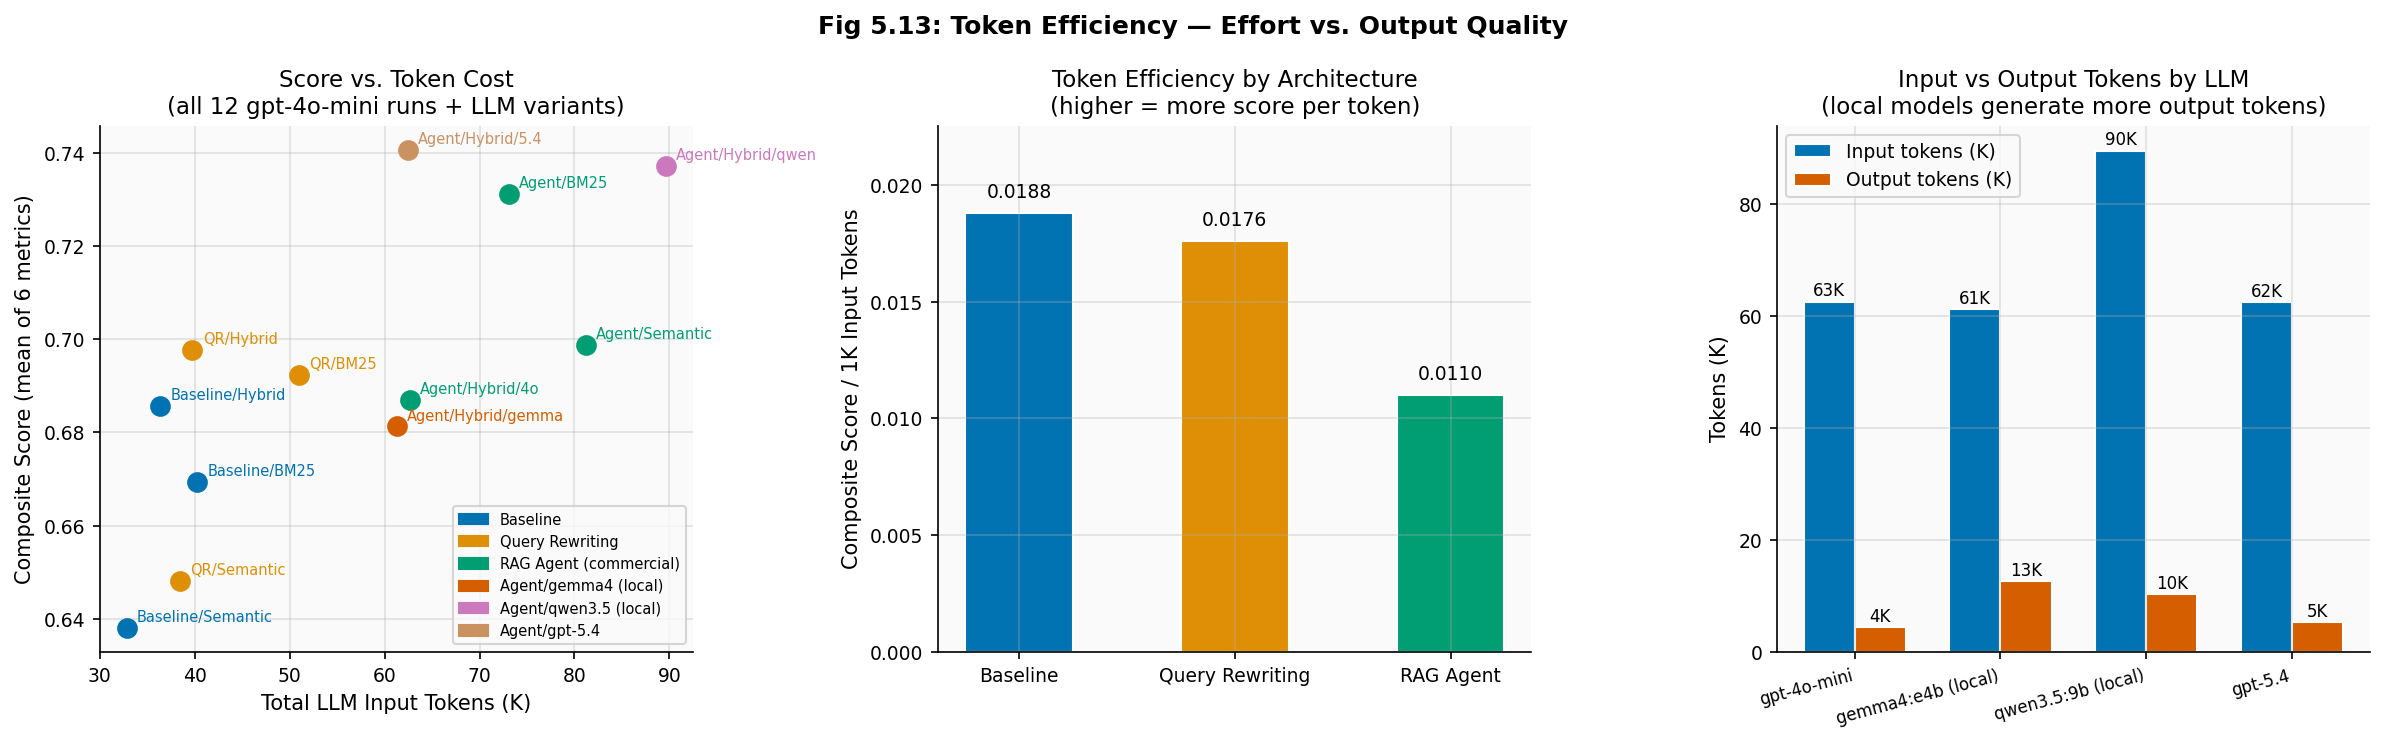

In [28]:
# ── Fig 5.13: Scatter + bar — Architecture efficiency ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Scatter — all 12 runs (composite score vs input tokens) ────────────
ALL_RUNS_EFF = [
    ('f6d783f661a644a58865384534021c32', 'Baseline/Semantic', PALETTE[0]),
    ('144d504d4b1b454f8505f54697c69250', 'Baseline/BM25',     PALETTE[0]),
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Baseline/Hybrid',   PALETTE[0]),
    ('92647f9427f74a0ea710d0cf731ec0ea', 'QR/Semantic',       PALETTE[1]),
    ('e5483a9635b34c8895ecdfabc45674c4', 'QR/BM25',           PALETTE[1]),
    ('412a730db5e04a4da436218d6321d1cd', 'QR/Hybrid',         PALETTE[1]),
    ('7b33b7a6b88b420e93d6c56f8bca4416', 'Agent/Semantic',    PALETTE[2]),
    ('2c80aecbb48d4bf68efce97806509159', 'Agent/BM25',        PALETTE[2]),
    ('9df381d8997646e797d34917dd394dee', 'Agent/Hybrid/4o',   PALETTE[2]),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'Agent/Hybrid/gemma',PALETTE[3]),
    ('801c6a24a60b4f689a38fcdb1de87e49', 'Agent/Hybrid/qwen', PALETTE[4]),
    ('9d312a36ef2f4332b200b620919bd202', 'Agent/Hybrid/5.4',  PALETTE[5]),
]

ax = axes[0]
arch_legend = {
    'Baseline':     mpatches.Patch(color=PALETTE[0], label='Baseline'),
    'Query Rewrit.':mpatches.Patch(color=PALETTE[1], label='Query Rewrit.'),
    'RAG Agent':    mpatches.Patch(color=PALETTE[2], label='RAG Agent'),
    'Agent/local':  mpatches.Patch(color=PALETTE[3], label='Agent (local model)'),
}

for rid, label, color in ALL_RUNS_EFF:
    tokens = load_token_metrics(rid)
    score = mean_scores(all_data[rid])[METRIC_COLS].mean()
    x_val = tokens['total_llm_input_tokens'] / 1000
    ax.scatter(x_val, score, color=color, s=80, zorder=3)
    ax.annotate(label, (x_val, score), textcoords='offset points',
                xytext=(5, 3), fontsize=7, color=color)

ax.set_xlabel('Total LLM Input Tokens (K)')
ax.set_ylabel('Composite Score (mean of 6 metrics)')
ax.set_title('Score vs. Token Cost\n(all 12 gpt-4o-mini runs + LLM variants)')
legend_handles = [
    mpatches.Patch(color=PALETTE[0], label='Baseline'),
    mpatches.Patch(color=PALETTE[1], label='Query Rewriting'),
    mpatches.Patch(color=PALETTE[2], label='RAG Agent (commercial)'),
    mpatches.Patch(color=PALETTE[3], label='Agent/gemma4 (local)'),
    mpatches.Patch(color=PALETTE[4], label='Agent/qwen3.5 (local)'),
    mpatches.Patch(color=PALETTE[5], label='Agent/gpt-5.4'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

# ── Plot 2: Score-per-1K-tokens — architecture axis ────────────────────────────
ax = axes[1]
labels2 = list(eff_axis2.index)
vals2 = eff_axis2['score_per_1k_tokens'].values
colors2 = PALETTE[:len(labels2)]
bars = ax.bar(labels2, vals2, color=colors2, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Composite Score / 1K Input Tokens')
ax.set_title('Token Efficiency by Architecture\n(higher = more score per token)')
ax.set_ylim(0, max(vals2) * 1.2)

# ── Plot 3: Input vs Output tokens — LLM axis (local verbosity) ────────────────
ax = axes[2]
labels3 = list(eff_axis3.index)
x3 = np.arange(len(labels3))
w = 0.35
in_vals  = eff_axis3['input_tokens_K'].values
out_vals = eff_axis3['output_tokens_K'].values
b1 = ax.bar(x3 - w/2, in_vals,  w, label='Input tokens (K)',  color=PALETTE[0], edgecolor='white')
b2 = ax.bar(x3 + w/2, out_vals, w, label='Output tokens (K)', color=PALETTE[3], edgecolor='white')
for bar, v in zip(list(b1) + list(b2), list(in_vals) + list(out_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.0f}K', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x3)
ax.set_xticklabels(labels3, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Tokens (K)')
ax.set_title('Input vs Output Tokens by LLM\n(local models generate more output tokens)')
ax.legend()

plt.suptitle('Fig 5.13: Token Efficiency — Effort vs. Output Quality',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_13_token_efficiency')
plt.show()

---
## Summary Checklist for Thesis Writing

Use this as a writing checklist when drafting Chapter 5:

**5.1.4 Judge Validity Study**
- [ ] Report reproducibility delta table (Table 5.1.4a) — note any metric with |Δ| > 0.05  
- [ ] Report judge comparison mean scores (Table 5.1.4b)
- [ ] Report Pearson correlation table (Table 5.1.4c)
- [ ] Justify gpt-4o-mini as fixed judge
- [ ] Add caveat for faithfulness and factual_correctness

**5.1.5 Experiment Design**
- [ ] Include design matrix (Table 5.1)
- [ ] Explain question class distribution and why unanswerable is excluded from aggregates
- [ ] Justify staged axis design (reduces from O(n³) to O(3n) runs)

**5.1.6 Axis 1 — Search Strategy**
- [ ] Include Table 5.2 + delta table
- [ ] Include Fig 5.3 (bar + delta chart)
- [ ] Include Fig 5.4 (3×3 grid heatmap) as supplementary or in appendix
- [ ] Discuss BM25 > semantic finding in context of QSD domain

**5.1.7 Axis 2 — Architecture**
- [ ] Include Table 5.3 + delta table
- [ ] Include Fig 5.5 or Fig 5.6 (bar chart or radar)
- [ ] Discuss faithfulness–recall trade-off
- [ ] Explain why RAG Agent was selected for Axis 3

**5.1.8 Axis 3 — LLM Model**
- [ ] Include Table 5.4 + delta table
- [ ] Include Fig 5.8 or Fig 5.9
- [ ] Include local vs commercial comparison (Table 5.4c)
- [ ] Discuss qwen3.5:9b viability as local model

**5.1.9 Best Configuration**
- [ ] Include Fig 5.10 (by question class)
- [ ] Include Fig 5.11 (by subdomain — heatmap)
- [ ] Include Fig 5.12 (all runs overview heatmap)
- [ ] State recommendation for primary deployment scenario

**5.1.10 Token Efficiency**
- [ ] Include Table 5.6b (architecture cost multiplier)
- [ ] Include Table 5.6d (LLM model token usage)
- [ ] Include Fig 5.13 (scatter + efficiency bar + verbosity chart)
- [ ] Discuss architecture cost-accuracy trade-off (RAG Agent 1.7× tokens, quantified score gain)
- [ ] Discuss local model verbosity (3× output tokens, higher latency)
- [ ] State efficiency recommendation for latency-sensitive vs quality-focused deployments

---
<a id='latex-table-export'></a>
## LaTeX Table Export

Run this section to export all tables as LaTeX for direct inclusion in the thesis.

In [29]:
LATEX_DIR = Path('latex_tables')
LATEX_DIR.mkdir(exist_ok=True)

METRIC_RENAME = {
    'faithfulness':             'Faithfulness',
    'context_precision':        'Ctx. Prec.',
    'context_recall':           'Ctx. Rec.',
    'answer_relevance':         'Ans. Rel.',
    'factual_correctness':      'FC',
    'factual_correctness_recall': 'FC Rec.',
}

def to_latex(df: pd.DataFrame, filename: str, caption: str, label: str,
             bold_max: bool = True):
    df_out = df.rename(columns=METRIC_RENAME)
    if bold_max:
        # Bold the maximum value in each column
        latex_lines = []
        for col in df_out.columns:
            max_idx = df_out[col].idxmax()
            df_out[col] = df_out[col].apply(
                lambda v, m=df_out.loc[max_idx, col]: f'\\textbf{{{v:.4f}}}' if v == m else f'{v:.4f}'
            )
    latex = df_out.to_latex(
        escape=False,
        caption=caption,
        label=label,
        column_format='l' + 'r' * len(df_out.columns),
        position='htbp',
    )
    path = LATEX_DIR / filename
    path.write_text(latex)
    print(f'  Saved: latex_tables/{filename}')
    return latex


tables = [
    (axis1_table,  'table_axis1_search.tex',
     'Search Strategy Comparison (Baseline arch, gpt-4o-mini)',
     'tab:axis1_search'),
    (axis2_table,  'table_axis2_arch.tex',
     'RAG Architecture Comparison (Hybrid search, gpt-4o-mini)',
     'tab:axis2_arch'),
    (build_table(AXIS3_RUNS_CLEAN), 'table_axis3_llm.tex',
     'LLM Model Comparison (RAG Agent, Hybrid search)',
     'tab:axis3_llm'),
    (judge_means,  'table_judge_comparison.tex',
     'Inter-Judge Score Comparison (same precomputed answers)',
     'tab:judge_comparison'),
    (overview_table, 'table_all_runs.tex',
     'All Runs — Mean RAGAS Scores (excl. unanswerable)',
     'tab:all_runs'),
]

print('Exporting LaTeX tables...')
for df, filename, caption, label in tables:
    to_latex(df, filename, caption, label)

Exporting LaTeX tables...
  Saved: latex_tables/table_axis1_search.tex
  Saved: latex_tables/table_axis2_arch.tex
  Saved: latex_tables/table_axis3_llm.tex
  Saved: latex_tables/table_judge_comparison.tex
  Saved: latex_tables/table_all_runs.tex


In [30]:
# Preview one table
print('Preview — Axis 2 Architecture table (LaTeX):')
print((LATEX_DIR / 'table_axis2_arch.tex').read_text())

Preview — Axis 2 Architecture table (LaTeX):
\begin{table}[htbp]
\caption{RAG Architecture Comparison (Hybrid search, gpt-4o-mini)}
\label{tab:axis2_arch}
\begin{tabular}{lrrrrrr}
\toprule
 & Faithfulness & Ctx. Prec. & Ctx. Rec. & Ans. Rel. & FC & FC Rec. \\
\midrule
Baseline & \textbf{0.8058} & \textbf{0.7521} & 0.6111 & 0.8889 & 0.4740 & 0.5827 \\
Query Rewriting & 0.8045 & 0.7146 & \textbf{0.6222} & 0.8642 & \textbf{0.5247} & 0.6560 \\
RAG Agent & 0.7156 & 0.7113 & 0.6190 & \textbf{0.9044} & 0.4660 & \textbf{0.7053} \\
\bottomrule
\end{tabular}
\end{table}



---
## Summary Checklist for Thesis Writing

Use this as a writing checklist when drafting Chapter 5:

**5.1.4 Judge Validity Study**
- [ ] Report reproducibility delta table (Table 5.1.4a) — note any metric with |Δ| > 0.05  
- [ ] Report judge comparison mean scores (Table 5.1.4b)
- [ ] Report Pearson correlation table (Table 5.1.4c)
- [ ] Justify gpt-4o-mini as fixed judge
- [ ] Add caveat for faithfulness and factual_correctness

**5.1.5 Experiment Design**
- [ ] Include design matrix (Table 5.1)
- [ ] Explain question class distribution and why unanswerable is excluded from aggregates
- [ ] Justify staged axis design (reduces from O(n³) to O(3n) runs)

**5.1.6 Axis 1 — Search Strategy**
- [ ] Include Table 5.2 + delta table
- [ ] Include Fig 5.3 (bar + delta chart)
- [ ] Include Fig 5.4 (3×3 grid heatmap) as supplementary or in appendix
- [ ] Discuss BM25 > semantic finding in context of QSD domain

**5.1.7 Axis 2 — Architecture**
- [ ] Include Table 5.3 + delta table
- [ ] Include Fig 5.5 or Fig 5.6 (bar chart or radar)
- [ ] Discuss faithfulness–recall trade-off
- [ ] Explain why RAG Agent was selected for Axis 3

**5.1.8 Axis 3 — LLM Model**
- [ ] Include Table 5.4 + delta table
- [ ] Include Fig 5.8 or Fig 5.9
- [ ] Include local vs commercial comparison (Table 5.4c)
- [ ] Discuss qwen3.5:9b viability as local model

**5.1.9 Best Configuration**
- [ ] Include Fig 5.10 (by question class)
- [ ] Include Fig 5.11 (by subdomain — heatmap)
- [ ] Include Fig 5.12 (all runs overview heatmap)
- [ ] State recommendation for primary deployment scenario